<h1>Виконання курсової роботи </h1>
<h1>на тему: "Аналіз та прогнозування дохідності інвестиційних активів під впливом ключових макроекономічних факторів"</h1>
<h1>з дисципліни "Аналіз даних в інформаційних системах"</h1>

<p>Для дослідження впливу макроекономічних факторів на дохідність інвестиційних активів було виконано наступні етапи аналізу:</p>
<ol>
    <li><strong>Підготовка фінального датасету</strong> - об'єднання даних про активи, ВВП, інфляцію, реальні процентні ставки та безробіття в один структурований набір даних з річною гранулярністю</li>
    <li><strong>Кореляційний аналіз</strong> - визначення лінійних зв'язків між макроекономічними показниками та дохідністю активи, перевірка статистичної значущості</li>
    <li><strong>Регресійний аналіз</strong> - побудова та порівняння лінійної, множинної та поліноміальної регресій для прогнозування дохідності</li>
    <li><strong>Оцінка якості моделей</strong> - розділення даних на навчальну та тестову вибірки, виявлення перенавчання</li>
    <li><strong>Класифікація напрямку зміни дохідності</strong> - застосування методів KNN, Decision Tree, Random Forest, AdaBoost, SVC для передбачення зростання чи падіння дохідності</li>
    <li><strong>Прогнозування часових рядів</strong> - використання моделей ARIMA та SARIMAX для прогнозу дохідності на наступний рік</li>
</ol>

<h2>1. Підготовка фінального датасету для аналізу</h2>

<p>Об'єднання всіх очищених даних з лабораторної 1-2 в один датафрейм для побудови машинного навчання </p>

<p>Об'єднання активів у сховищі виконано для уніфікації структури даних. Розділення на акції та криптовалюти перед аналізом дозволяє порівняти, як по-різному макроекономічні фактори впливають на традиційний фондовий ринок та цифрові активи.</p>
<p>Джерелом даних для аналізу є Oracle Database (сховище даних), створене в рамках лабораторних робіт АД1-АД2. Дані витягуються за допомогою SQL-запитів безпосередньо з таблиць Stage-зони.</p>

In [1]:
# Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
import statsmodels.tsa.stattools as smt
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
pd.set_option('display.float_format', '{:,.8f}'.format)

In [3]:
# Шлях до очищених файлів з лабораторної АД 1-2
path = r"C:/Users/stepa/Desktop/АДІС/KP_ADIS_Macroeconomic_analysis/ADIS_Project_clean_datasets/"

# Зчитуємо очищені дані
df_assets = pd.read_csv(path + "assets_clean.csv", encoding='cp1252')
df_gdp = pd.read_csv(path + "gdp_clean.csv", encoding='cp1252')
df_inflation = pd.read_csv(path + "inflation_clean.csv", encoding='cp1252')
df_unemployment = pd.read_csv(path + "unemployment_clean.csv", encoding='cp1252')
df_real_interest = pd.read_csv(path + "real_interest_clean.csv", encoding='cp1252')


C:\Users\stepa\AppData\Local\Temp\ipykernel_18052\2971683284.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv(path + "assets_clean.csv", encoding='cp1252')


In [4]:
df_assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622262 entries, 0 to 622261
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          622262 non-null  object 
 1   open          622262 non-null  float64
 2   high          622262 non-null  float64
 3   low           622262 non-null  float64
 4   close         622262 non-null  float64
 5   volume        622262 non-null  float64
 6   brand_name    306445 non-null  object 
 7   ticker        622262 non-null  object 
 8   industry_tag  306445 non-null  object 
 9   country       622262 non-null  object 
 10  dividends     306445 non-null  float64
 11  stock_splits  306445 non-null  float64
 12  daily_return  306383 non-null  float64
 13  asset_type    622262 non-null  object 
 14  name          315817 non-null  object 
dtypes: float64(8), object(7)
memory usage: 71.2+ MB


In [5]:
df_real_interest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4576 entries, 0 to 4575
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country_code        4576 non-null   object 
 1   country             4576 non-null   object 
 2   year                4576 non-null   object 
 3   real_interest_rate  4576 non-null   float64
 4   indicator_name      4576 non-null   object 
dtypes: float64(1), object(4)
memory usage: 178.9+ KB


In [6]:
print('df_assets[country].nunique()): ', df_assets['country'].nunique())
print('df_gdp[country].nunique(): ', df_gdp['country'].nunique())
print('df_inflation[country].nunique(): ', df_inflation['country'].nunique())
print('df_unemployment[country].nunique(): ', df_unemployment['country'].nunique())
print('df_real_interest[country].nunique(): ', df_real_interest['country'].nunique())

df_assets[country].nunique()):  8
df_gdp[country].nunique():  199
df_inflation[country].nunique():  196
df_unemployment[country].nunique():  188
df_real_interest[country].nunique():  148


In [7]:
# Перетворюємо дати
df_assets['date'] = pd.to_datetime(df_assets['date'])
df_gdp['year'] = pd.to_datetime(df_gdp['year'])
df_inflation['year'] = pd.to_datetime(df_inflation['year'])
df_unemployment['year'] = pd.to_datetime(df_unemployment['year'])
df_real_interest['year'] = pd.to_datetime(df_real_interest['year'])

# Додаємо рік до df_assets для об'єднання з макропоказниками
df_assets['year'] = df_assets['date'].dt.year
df_assets.info()
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622262 entries, 0 to 622261
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   date          622262 non-null  datetime64[ns, UTC]
 1   open          622262 non-null  float64            
 2   high          622262 non-null  float64            
 3   low           622262 non-null  float64            
 4   close         622262 non-null  float64            
 5   volume        622262 non-null  float64            
 6   brand_name    306445 non-null  object             
 7   ticker        622262 non-null  object             
 8   industry_tag  306445 non-null  object             
 9   country       622262 non-null  object             
 10  dividends     306445 non-null  float64            
 11  stock_splits  306445 non-null  float64            
 12  daily_return  306383 non-null  float64            
 13  asset_type    622262 non-null  object       

In [8]:
# Для аналізу розділимо  df_assets на два датафрейми - df_crypto, df_stock
df_stocks = df_assets[df_assets['asset_type'] == 'Stock'].copy()
df_crypto = df_assets[df_assets['asset_type'] == 'Crypto'].copy()

print(f"Розділення активів:")
print(f" Акції: {len(df_stocks)} рядків")
print(f" Криптовалюти: {len(df_crypto)} рядків")

Розділення активів:
 Акції: 306445 рядків
 Криптовалюти: 315817 рядків


In [9]:
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306445 entries, 0 to 591825
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   date          306445 non-null  datetime64[ns, UTC]
 1   open          306445 non-null  float64            
 2   high          306445 non-null  float64            
 3   low           306445 non-null  float64            
 4   close         306445 non-null  float64            
 5   volume        306445 non-null  float64            
 6   brand_name    306445 non-null  object             
 7   ticker        306445 non-null  object             
 8   industry_tag  306445 non-null  object             
 9   country       306445 non-null  object             
 10  dividends     306445 non-null  float64            
 11  stock_splits  306445 non-null  float64            
 12  daily_return  306383 non-null  float64            
 13  asset_type    306445 non-null  object            

In [10]:
df_crypto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 315817 entries, 153698 to 622261
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   date          315817 non-null  datetime64[ns, UTC]
 1   open          315817 non-null  float64            
 2   high          315817 non-null  float64            
 3   low           315817 non-null  float64            
 4   close         315817 non-null  float64            
 5   volume        315817 non-null  float64            
 6   brand_name    0 non-null       object             
 7   ticker        315817 non-null  object             
 8   industry_tag  0 non-null       object             
 9   country       315817 non-null  object             
 10  dividends     0 non-null       float64            
 11  stock_splits  0 non-null       float64            
 12  daily_return  0 non-null       float64            
 13  asset_type    315817 non-null  object       

In [11]:
# Перераховуємо daily_return для крипти
df_crypto = df_crypto.sort_values(['ticker', 'date'])

df_crypto['daily_return'] = df_crypto.groupby('ticker')['close'].pct_change() * 100

#видалення колонок 
df_crypto = df_crypto.drop(columns=['brand_name', 'industry_tag', 'dividends', 'stock_splits'])
df_stocks = df_stocks.drop(columns='name')

df_stocks.info()
df_crypto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306445 entries, 0 to 591825
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   date          306445 non-null  datetime64[ns, UTC]
 1   open          306445 non-null  float64            
 2   high          306445 non-null  float64            
 3   low           306445 non-null  float64            
 4   close         306445 non-null  float64            
 5   volume        306445 non-null  float64            
 6   brand_name    306445 non-null  object             
 7   ticker        306445 non-null  object             
 8   industry_tag  306445 non-null  object             
 9   country       306445 non-null  object             
 10  dividends     306445 non-null  float64            
 11  stock_splits  306445 non-null  float64            
 12  daily_return  306383 non-null  float64            
 13  asset_type    306445 non-null  object            

<p>Оскільки макроекономічні показники (ВВП, інфляція, процентні ставки, безробіття) мають річну частоту, а дохідність активів розрахована на щоденній основі, виникла необхідність узгодити гранулярність даних. Агрегування щоденної дохідності до річного рівня є більш коректним підходом порівняно з альтернативним «розтягуванням» річних показників на кожен день, оскільки останній створював би штучну залежність між сусідніми днями та спотворював статистичні оцінки. Розрахована середньорічна дохідність краще відображає довгостроковий вплив макроекономічних факторів на інвестиційну привабливість активів.</p>

In [12]:
# Агрегуємо дохідність по роках
# Макроекономічні показники (ВВП, інфляція, безробіття) - річні. А дохідність активів daily_return - щоденна
# Треба привести всі дані до одного рівня деталізації (гранулярності), тому агрегуємо щоденну дохідність за рік
# Для акцій - зберігаємо всі колонки
stocks_yearly = df_stocks.groupby(['country', 'year']).agg({
    # Цінові показники (усереднюємо)
    'open': 'mean',
    'high': 'mean',
    'low': 'mean',
    'close': 'mean',
    'volume': 'mean',
    
    # Дохідність (усереднюємо)
    'daily_return': 'mean',
    
    # Дивіденди та спліти (сумуємо за рік)
    'dividends': 'sum',
    'stock_splits': 'sum',
    
    # Ідентифікатори акцій (беремо перше значення, вони не змінюються)
    'ticker': 'first',
    'brand_name': 'first',
    'industry_tag': 'first',
    'asset_type': 'first'
}).reset_index()

# Перейменовуємо колонку daily_return
stocks_yearly = stocks_yearly.rename(columns={'daily_return': 'avg_daily_return_stocks'})

# Перевіряємо, що вийшло
print("Колонки в stocks_yearly:")
print(stocks_yearly.columns.tolist())
print(f"\nРозмір: {stocks_yearly.shape}")
print(stocks_yearly.head())

Колонки в stocks_yearly:
['country', 'year', 'open', 'high', 'low', 'close', 'volume', 'avg_daily_return_stocks', 'dividends', 'stock_splits', 'ticker', 'brand_name', 'industry_tag', 'asset_type']

Розмір: (155, 14)
  country  year        open        high         low       close  \
0  Canada  2015  3.07257325  3.16238789  2.96878853  3.05927388   
1  Canada  2016  3.33753969  3.39746387  3.26969683  3.33388890   
2  Canada  2017  8.67134941  8.82712112  8.50650398  8.67998409   
3  Canada  2018 14.09200557 14.41320122 13.79194221 14.11059362   
4  Canada  2019 27.98189687 28.56422225 27.45548329 28.06736111   

               volume  avg_daily_return_stocks  dividends  stock_splits  \
0  5,311,076.43312102               0.00414035 0.00000000    0.00000000   
1  7,988,087.30158730               0.00244463 0.00000000    0.00000000   
2 20,229,968.12749004               0.00379214 0.00000000    0.00000000   
3 17,077,087.64940239               0.00183957 0.00000000    0.00000000   
4 19,8

<p>Для криптовалют у використаних джерелах даних країною за замовчуванням вказано умовне значення "World". Оскільки макроекономічні показники (ВВП, інфляція, процентні ставки, безробіття) не публікуються для глобального ринку в цілому, пряме об'єднання криптовалют з макропоказниками неможливе.</p>
<p>Однак, враховуючи, що більшість криптовалют торгуються в парах з доларом США та реагують на монетарну політику Федеральної резервної системи США (ФРС), для подальшого дослідження пропонується замінити країну "World" на "United States of America". Це дозволить аналізувати вплив макроекономічних факторів США на дохідність криптовалют та порівнювати їх з акціями США</p>

In [13]:
# Для криптовалют аналогічнно агрегуємо дохідність по роках
crypto_yearly = df_crypto.groupby(['country', 'year']).agg({
    'open': 'mean',
    'high': 'mean',
    'low': 'mean',
    'close': 'mean',
    'volume': 'mean',
    'daily_return': 'mean',
    'ticker': 'first',
    'name': 'first',
    'asset_type': 'first'
}).reset_index()

crypto_yearly = crypto_yearly.rename(columns={'daily_return': 'avg_daily_return_crypto'})

# Прив'язка до США замість World
crypto_yearly['country'] = 'United States of America'

print("Колонки в crypto_yearly (після прив'язки до США):")
crypto_yearly[['country', 'year', 'avg_daily_return_crypto', 'ticker', 'name']].head()

Колонки в crypto_yearly (після прив'язки до США):


,country,year,avg_daily_return_crypto,ticker,name
0,United States of America,2014,-0.41296432,BTC-USD,Bitcoin
1,United States of America,2015,0.20633149,BTC-USD,Bitcoin
2,United States of America,2016,0.17788060,BTC-USD,Bitcoin
3,United States of America,2017,2.64862421,ADA-USD,Cardano
4,United States of America,2018,0.02119313,ADA-USD,Cardano


In [14]:
stocks_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  155 non-null    object 
 1   year                     155 non-null    int32  
 2   open                     155 non-null    float64
 3   high                     155 non-null    float64
 4   low                      155 non-null    float64
 5   close                    155 non-null    float64
 6   volume                   155 non-null    float64
 7   avg_daily_return_stocks  155 non-null    float64
 8   dividends                155 non-null    float64
 9   stock_splits             155 non-null    float64
 10  ticker                   155 non-null    object 
 11  brand_name               155 non-null    object 
 12  industry_tag             155 non-null    object 
 13  asset_type               155 non-null    object 
dtypes: float64(8), int32(1), o

In [15]:
crypto_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  12 non-null     object 
 1   year                     12 non-null     int32  
 2   open                     12 non-null     float64
 3   high                     12 non-null     float64
 4   low                      12 non-null     float64
 5   close                    12 non-null     float64
 6   volume                   12 non-null     float64
 7   avg_daily_return_crypto  12 non-null     float64
 8   ticker                   12 non-null     object 
 9   name                     12 non-null     object 
 10  asset_type               12 non-null     object 
dtypes: float64(6), int32(1), object(4)
memory usage: 1.1+ KB


In [16]:
print("\ndf_gdp.info()")
df_gdp.info()
print("\ndf_gdp['year'].describe(include = \"all\")\n", df_gdp['year'].describe(include = "all"))

print("\ndf_inflation.info()")
df_inflation.info()
print("\ndf_inflation['year'].describe(include = \"all\")\n", df_inflation['year'].describe(include = "all"))

print("\ndf_real_interest.info()")
df_real_interest.info()
print("\ndf_real_interest['year'].describe(include = \"all\")\n", df_real_interest['year'].describe(include = "all"))

print("\ndf_unemployment.info()")
df_unemployment.info()
print("\ndf_unemployment['year'].describe(include = \"all\")\n", df_unemployment['year'].describe(include = "all"))



df_gdp.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   country         6567 non-null   object             
 1   country_code    6567 non-null   object             
 2   year            6567 non-null   datetime64[ns, UTC]
 3   gdp_value       6567 non-null   float64            
 4   indicator_name  6567 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 256.7+ KB

df_gdp['year'].describe(include = "all")
 count                                   6567
mean     2005-12-31 21:05:27.272727296+00:00
min                1990-01-01 00:00:00+00:00
25%                1998-01-01 00:00:00+00:00
50%                2006-01-01 00:00:00+00:00
75%                2014-01-01 00:00:00+00:00
max                2022-01-01 00:00:00+00:00
Name: year, dtype: object

df_inflation.info

<p>Аналіз часових діапазонів наявних даних показав, що показник безробіття доступний лише з 2014 року, тоді як ВВП та інфляція охоплюють період з 1990 року, а реальні процентні ставки - до 2021 року. Спільний період для всіх чотирьох макроекономічних факторів становить 2014-2021 роки. Для збереження репрезентативності вибірки було виконано два окремі дослідження: перше охоплює розширений період 1990-2021 роки без врахування фактору безробіття (використовуючи 21 511 спостережень), друге - період 2014-2021 роки з повним набором факторів, включно з безробіттям. Такий підхід дозволяє оцінити, чи додає включення показника безробіття статистичну значущість до прогнозних моделей, та порівняти результати на різних часових проміжках</p>

In [17]:
#видалення колонок для подальшого об'єднання макроекономічних показників
df_gdp = df_gdp.drop(columns=['indicator_name', 'country_code'])
df_inflation = df_inflation.drop(columns='indicator_name')
df_real_interest = df_real_interest.drop(columns=['indicator_name', 'country_code'])

#перетворення типу datetime в ціле число
df_gdp['year'] = pd.to_datetime(df_gdp['year']).dt.year
df_inflation['year'] = pd.to_datetime(df_inflation['year']).dt.year
df_unemployment['year'] = pd.to_datetime(df_unemployment['year']).dt.year
df_real_interest['year'] = pd.to_datetime(df_real_interest['year']).dt.year

In [18]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    6567 non-null   object 
 1   year       6567 non-null   int32  
 2   gdp_value  6567 non-null   float64
dtypes: float64(1), int32(1), object(1)
memory usage: 128.4+ KB


In [19]:
# агрегація безробіття
df_unemployment_agg = df_unemployment.groupby(['country', 'year'])['unemployment_rate_value'].mean().reset_index()

print(f"Безробіття до: {df_unemployment.shape[0]} рядків")
print(f"Безробіття після: {df_unemployment_agg.shape[0]} рядків")

Безробіття до: 12378 рядків
Безробіття після: 2063 рядків


<p>Акції та криптовалюти є принципово різними класами інвестиційних активів. Акції представляють частку у власності компаній, їхня вартість визначається фундаментальними показниками бізнесу (прибутки, дивіденди, грошові потоки). Криптовалюти не мають такого фундаментального обґрунтування, їхня ціна визначається виключно співвідношенням попиту та пропозиції. Тому для коректності дослідження аналіз виконується окремо для акцій та криптовалют</p>

<h4>Обєднання датасету акцій з макропоказниками</h4>

In [20]:
# Об'єднуємо макропоказники (без безробіття) та дохідність акцій за країною і роком, видаляючи пропуски для максимального охоплення періоду.
# АНАЛІЗ 1 - ВСІ ФАКТОРИ, БЕЗ БЕЗРОБІТТЯ (для більшого періоду)
macro_data_no_unemployment = df_gdp[['country', 'year', 'gdp_value']].copy()
macro_data_no_unemployment = macro_data_no_unemployment.merge(
    df_inflation[['country', 'year', 'inflation_value']], 
    on=['country', 'year'], how='outer'
)
macro_data_no_unemployment = macro_data_no_unemployment.merge(
    df_real_interest[['country', 'year', 'real_interest_rate']], 
    on=['country', 'year'], how='outer'
)

stocks_analysis_no_unemployment = macro_data_no_unemployment.merge(
    stocks_yearly[['country', 'year', 'avg_daily_return_stocks']], 
    left_on=['country', 'year'], right_on=['country', 'year'], 
    how='inner'
)

stocks_analysis_no_unemployment = stocks_analysis_no_unemployment.dropna(
    subset=['gdp_value', 'inflation_value', 'real_interest_rate', 'avg_daily_return_stocks']
)

print(f"АНАЛІЗ 1 (без безробіття): {stocks_analysis_no_unemployment.shape}")
print(f"Діапазон років: {stocks_analysis_no_unemployment['year'].min()} - {stocks_analysis_no_unemployment['year'].max()}")


АНАЛІЗ 1 (без безробіття): (71, 6)
Діапазон років: 2000 - 2021


In [21]:
# Фільтруємо всі датасети за спільним періодом 2014-2021 років та об'єднуємо їх за країною і роком, включаючи показник безробіття.
# АНАЛІЗ 2 - З БЕЗРОБІТТЯМ, ТІЛЬКИ 2014-2021 (спільний період)

# Визначаємо спільний період для всіх показників
# З unemployment: 2014-2024
# З real_interest: до 2021
# Тому спільний період: 2014-2021
start_year = 2014
end_year = 2021

df_gdp_filtered = df_gdp[(df_gdp['year'] >= start_year) & (df_gdp['year'] <= end_year)]
df_inflation_filtered = df_inflation[(df_inflation['year'] >= start_year) & (df_inflation['year'] <= end_year)]
df_real_interest_filtered = df_real_interest[(df_real_interest['year'] >= start_year) & (df_real_interest['year'] <= end_year)]
df_unemployment_filtered = df_unemployment_agg[(df_unemployment_agg['year'] >= start_year) & (df_unemployment_agg['year'] <= end_year)]

macro_data_with_unemployment = df_gdp_filtered[['country', 'year', 'gdp_value']].copy()
macro_data_with_unemployment = macro_data_with_unemployment.merge(
    df_inflation_filtered[['country', 'year', 'inflation_value']], 
    on=['country', 'year'], how='outer'
)
macro_data_with_unemployment = macro_data_with_unemployment.merge(
    df_real_interest_filtered[['country', 'year', 'real_interest_rate']], 
    on=['country', 'year'], how='outer'
)
macro_data_with_unemployment = macro_data_with_unemployment.merge(
    df_unemployment_filtered[['country', 'year', 'unemployment_rate_value']], 
    on=['country', 'year'], how='outer'
)


stocks_analysis_with_unemployment = macro_data_with_unemployment.merge(
    stocks_yearly[['country', 'year', 'avg_daily_return_stocks']], 
    left_on=['country', 'year'], right_on=['country', 'year'], 
    how='inner'
)

stocks_analysis_with_unemployment = stocks_analysis_with_unemployment.dropna(
    subset=['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value', 'avg_daily_return_stocks']
)

print(f"АНАЛІЗ 2 (з безробіттям): {stocks_analysis_with_unemployment.shape}")
print(f"Діапазон років: {stocks_analysis_with_unemployment['year'].min()} - {stocks_analysis_with_unemployment['year'].max()}")


АНАЛІЗ 2 (з безробіттям): (23, 7)
Діапазон років: 2014 - 2021


In [22]:
#Перевіряємо результати
print("ПЕРШІ 5 РЯДКІВ (АНАЛІЗ 1 - без безробіття):\n")
stocks_analysis_no_unemployment.head()

ПЕРШІ 5 РЯДКІВ (АНАЛІЗ 1 - без безробіття):



,country,year,gdp_value,inflation_value,real_interest_rate,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,0.00379214
48,Japan,2000,"4,968,359,152,796.00000000",-0.70000000,3.44952133,-0.00028303
49,Japan,2001,"4,374,709,984,220.00000000",-0.70000000,3.08779538,0.00043297


In [23]:
print("ПЕРШІ 5 РЯДКІВ (АНАЛІЗ 2 - з безробіттям):\n")
stocks_analysis_with_unemployment.head()

ПЕРШІ 5 РЯДКІВ (АНАЛІЗ 2 - з безробіттям):



,country,year,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,8.52616667,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,8.54950000,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,7.74316667,0.00379214
23,Japan,2014,"4,896,994,405,353.00000000",2.80000000,-0.45938159,4.39216667,-0.00055855
24,Japan,2015,"4,444,930,651,964.00000000",0.80000000,-0.94844123,3.99700000,0.00074717


In [24]:
#скидання індексів
stocks_analysis_no_unemployment = stocks_analysis_no_unemployment.reset_index(drop=True)
stocks_analysis_with_unemployment = stocks_analysis_with_unemployment.reset_index(drop=True)

stocks_analysis_no_unemployment.head()

,country,year,gdp_value,inflation_value,real_interest_rate,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,0.00379214
3,Japan,2000,"4,968,359,152,796.00000000",-0.70000000,3.44952133,-0.00028303
4,Japan,2001,"4,374,709,984,220.00000000",-0.70000000,3.08779538,0.00043297


In [25]:
stocks_analysis_with_unemployment.head()

,country,year,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,8.52616667,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,8.54950000,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,7.74316667,0.00379214
3,Japan,2014,"4,896,994,405,353.00000000",2.80000000,-0.45938159,4.39216667,-0.00055855
4,Japan,2015,"4,444,930,651,964.00000000",0.80000000,-0.94844123,3.99700000,0.00074717


In [26]:
# Описова статистика для акцій (без безробіття)
print("Описова статистика stocks_analysis_no_unemployment:")
print(stocks_analysis_no_unemployment.describe().round(4))

# Кількість пропусків
print("\nПропущені значення в stocks_analysis_no_unemployment:")
print(stocks_analysis_no_unemployment.isnull().sum())

print("\nОписова статистика stocks_analysis_with_unemployment:")
print(stocks_analysis_with_unemployment.describe().round(4))

# Кількість пропусків
print("\nПропущені значення в stocks_analysis_with_unemployment:")
print(stocks_analysis_with_unemployment.isnull().sum())

Описова статистика stocks_analysis_no_unemployment:
                year                   gdp_value  inflation_value  \
count    71.00000000                 71.00000000      71.00000000   
mean  2,010.22540000  6,543,005,529,126.88769531       1.24080000   
std       5.89480000  6,872,633,826,989.07812500       1.46440000   
min   2,000.00000000    417,479,337,445.00000000      -1.30000000   
25%   2,005.50000000    730,246,539,118.50000000       0.00000000   
50%   2,010.00000000  4,579,749,785,985.00000000       1.30000000   
75%   2,015.00000000 11,836,817,619,500.00000000       2.30000000   
max   2,021.00000000 23,315,080,560,000.00000000       5.10000000   

       real_interest_rate  avg_daily_return_stocks  
count         71.00000000              71.00000000  
mean           2.22040000               0.00070000  
std            1.36950000               0.00120000  
min           -1.18940000              -0.00290000  
25%            1.41400000               0.00040000  
50%     

<h4>Обєднання датасету криптовалют з макропоказниками</h4>

In [27]:
# АНАЛІЗ 1 - ВСІ ФАКТОРИ, БЕЗ БЕЗРОБІТТЯ (для більшого періоду)
macro_data_no_unemployment_crypto = df_gdp[['country', 'year', 'gdp_value']].copy()
macro_data_no_unemployment_crypto = macro_data_no_unemployment_crypto.merge(
    df_inflation[['country', 'year', 'inflation_value']], 
    on=['country', 'year'], how='outer'
)
macro_data_no_unemployment_crypto = macro_data_no_unemployment_crypto.merge(
    df_real_interest[['country', 'year', 'real_interest_rate']], 
    on=['country', 'year'], how='outer'
)

crypto_analysis_no_unemployment = macro_data_no_unemployment_crypto.merge(
    crypto_yearly[['country', 'year', 'avg_daily_return_crypto']], 
    on=['country', 'year'], how='inner'
).dropna()

print(f"Розмір: {crypto_analysis_no_unemployment.shape}")
print(f"Діапазон років: {crypto_analysis_no_unemployment['year'].min()} - {crypto_analysis_no_unemployment['year'].max()}")
crypto_analysis_no_unemployment.head()

Розмір: (8, 6)
Діапазон років: 2014 - 2021


,country,year,gdp_value,inflation_value,real_interest_rate,avg_daily_return_crypto
0,United States of America,2014,"17,550,680,174,000.00000000",1.60000000,1.35477579,-0.41296432
1,United States of America,2015,"18,206,020,741,000.00000000",0.10000000,2.23707550,0.20633149
2,United States of America,2016,"18,695,110,842,000.00000000",1.30000000,2.48453034,0.17788060
3,United States of America,2017,"19,477,336,549,000.00000000",2.10000000,2.15609905,2.64862421
4,United States of America,2018,"20,533,057,312,000.00000000",2.40000000,2.44141503,0.02119313


In [28]:
# АНАЛІЗ 2 - З БЕЗРОБІТТЯМ, ТІЛЬКИ 2014-2021 (спільний період)
start_year_crypto = 2014
end_year_crypto = 2021

df_gdp_filtered_crypto = df_gdp[(df_gdp['year'] >= start_year_crypto) & (df_gdp['year'] <= end_year_crypto)]
df_inflation_filtered_crypto = df_inflation[(df_inflation['year'] >= start_year_crypto) & (df_inflation['year'] <= end_year_crypto)]
df_real_interest_filtered_crypto = df_real_interest[(df_real_interest['year'] >= start_year_crypto) & (df_real_interest['year'] <= end_year_crypto)]
df_unemployment_filtered_crypto = df_unemployment_agg[(df_unemployment_agg['year'] >= start_year_crypto) & (df_unemployment_agg['year'] <= end_year_crypto)]

macro_data_with_unemployment_crypto = df_gdp_filtered_crypto[['country', 'year', 'gdp_value']].copy()
macro_data_with_unemployment_crypto = macro_data_with_unemployment_crypto.merge(
    df_inflation_filtered_crypto[['country', 'year', 'inflation_value']], 
    on=['country', 'year'], how='outer'
)
macro_data_with_unemployment_crypto = macro_data_with_unemployment_crypto.merge(
    df_real_interest_filtered_crypto[['country', 'year', 'real_interest_rate']], 
    on=['country', 'year'], how='outer'
)
macro_data_with_unemployment_crypto = macro_data_with_unemployment_crypto.merge(
    df_unemployment_filtered_crypto[['country', 'year', 'unemployment_rate_value']], 
    on=['country', 'year'], how='outer'
)

crypto_analysis_with_unemployment = macro_data_with_unemployment_crypto.merge(
    crypto_yearly[['country', 'year', 'avg_daily_return_crypto']], 
    on=['country', 'year'], how='inner'
).dropna()

print(f"Розмір: {crypto_analysis_with_unemployment.shape}")
print(f"Діапазон років: {crypto_analysis_with_unemployment['year'].min()} - {crypto_analysis_with_unemployment['year'].max()}")
crypto_analysis_with_unemployment.head()


Розмір: (8, 7)
Діапазон років: 2014 - 2021


,country,year,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_crypto
0,United States of America,2014,"17,550,680,174,000.00000000",1.60000000,1.35477579,8.17433333,-0.41296432
1,United States of America,2015,"18,206,020,741,000.00000000",0.10000000,2.23707550,7.03816667,0.20633149
2,United States of America,2016,"18,695,110,842,000.00000000",1.30000000,2.48453034,6.41333333,0.17788060
3,United States of America,2017,"19,477,336,549,000.00000000",2.10000000,2.15609905,5.72350000,2.64862421
4,United States of America,2018,"20,533,057,312,000.00000000",2.40000000,2.44141503,5.22433333,0.02119313


In [29]:
# Описова статистика для акцій (без безробіття)
print("Описова статистика crypto_analysis_no_unemployment:")
print(crypto_analysis_no_unemployment.describe().round(4))

# Кількість пропусків
print("\nПропущені значення в crypto_analysis_no_unemployment:")
print(crypto_analysis_no_unemployment.isnull().sum())

print("\nОписова статистика crypto_analysis_with_unemployment:")
print(crypto_analysis_with_unemployment.describe().round(4))

# Кількість пропусків
print("\nПропущені значення в crypto_analysis_with_unemployment:")
print(crypto_analysis_with_unemployment.isnull().sum())

Описова статистика crypto_analysis_no_unemployment:
                year                   gdp_value  inflation_value  \
count     8.00000000                  8.00000000       8.00000000   
mean  2,017.50000000 20,027,341,988,750.00000000       1.91250000   
std       2.44950000  1,908,367,659,131.36767578       1.31960000   
min   2,014.00000000 17,550,680,174,000.00000000       0.10000000   
25%   2,015.75000000 18,572,838,316,750.00000000       1.30000000   
50%   2,017.50000000 20,005,196,930,500.00000000       1.70000000   
75%   2,019.25000000 21,140,599,239,500.00000000       2.17500000   
max   2,021.00000000 23,315,080,560,000.00000000       4.70000000   

       real_interest_rate  avg_daily_return_crypto  
count          8.00000000               8.00000000  
mean           1.89030000               2.82380000  
std            1.36710000               5.35000000  
min           -1.18940000              -0.41300000  
25%            1.95580000               0.13870000  
50%     

<h2>2. Кореляційний аналіз макрофакторів та дохідності</h2>

<p>Визначення, які макроекономічні фактори найбільше впливають на дохідність інвестиційних активів. </p>

<h4>Кореляційний аналіз для акцій</h4>

<p>Спробуємо використати stocks_analysis_no_unemployment, оскільки там більше даних</p>

In [30]:
df_corr = stocks_analysis_no_unemployment.copy()

# Вибір числових колонок для аналізу
numeric_cols = ['gdp_value', 'inflation_value', 'real_interest_rate', 'avg_daily_return_stocks']
df_numeric = df_corr[numeric_cols]

# Обчислення кореляційної матриці
corr_matrix = df_numeric.corr()
print("Кореляційна матриця:")
corr_matrix.round(4)

Кореляційна матриця:


,gdp_value,inflation_value,real_interest_rate,avg_daily_return_stocks
gdp_value,1.00000000,0.32860000,0.10270000,0.04550000
inflation_value,0.32860000,1.00000000,-0.25970000,-0.15800000
real_interest_rate,0.10270000,-0.25970000,1.00000000,-0.00400000
avg_daily_return_stocks,0.04550000,-0.15800000,-0.00400000,1.00000000


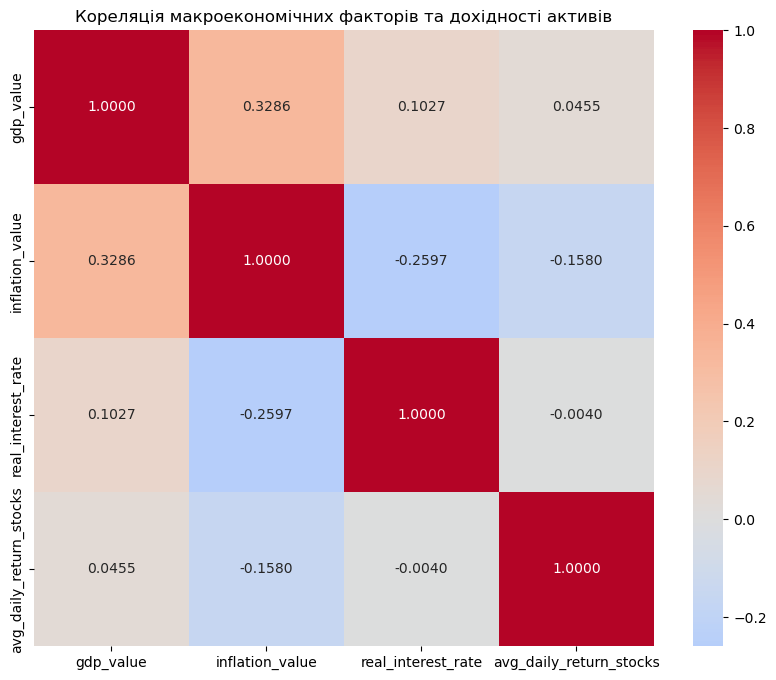

In [31]:
# Візуалізація теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.4f')
plt.title('Кореляція макроекономічних факторів та дохідності активів')
plt.show()

<p>З матриці видно, що всі коефіцієнти кореляції між макроекономічними факторами та дохідністю акцій є близькими до нуля (від -0.1580 до 0.0455). Найбільший за модулем зв'язок спостерігається між інфляцією та дохідністю (r = -0.1580), однак він не є статистично значущим (p = 0.1882). Жоден з досліджуваних факторів не демонструє лінійної залежності з дохідністю акцій. </p>

In [32]:
# Перевірка статистичної значущості кореляції для кожної пари
print("Перевірка статистичної значущості:")
for col in ['gdp_value', 'inflation_value', 'real_interest_rate']:
    # Видаляємо рядки з пропущеними значеннями для коректного розрахунку
    clean_data = df_corr[[col, 'avg_daily_return_stocks']].dropna()
    pearson_coef, p_value = stats.pearsonr(clean_data[col], clean_data['avg_daily_return_stocks'])
    print(f"\n{col} vs avg_daily_return_stocks:")
    print(f" Коефіцієнт Пірсона = {pearson_coef:.4f}")
    print(f" p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f" - Кореляція статистично значуща (p < 0.05)")
    else:
        print(f" - Кореляція НЕ статистично значуща (p > 0.05)")


Перевірка статистичної значущості:

gdp_value vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = 0.0455
 p-value = 0.7063
 - Кореляція НЕ статистично значуща (p > 0.05)

inflation_value vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = -0.1580
 p-value = 0.1882
 - Кореляція НЕ статистично значуща (p > 0.05)

real_interest_rate vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = -0.0040
 p-value = 0.9737
 - Кореляція НЕ статистично значуща (p > 0.05)


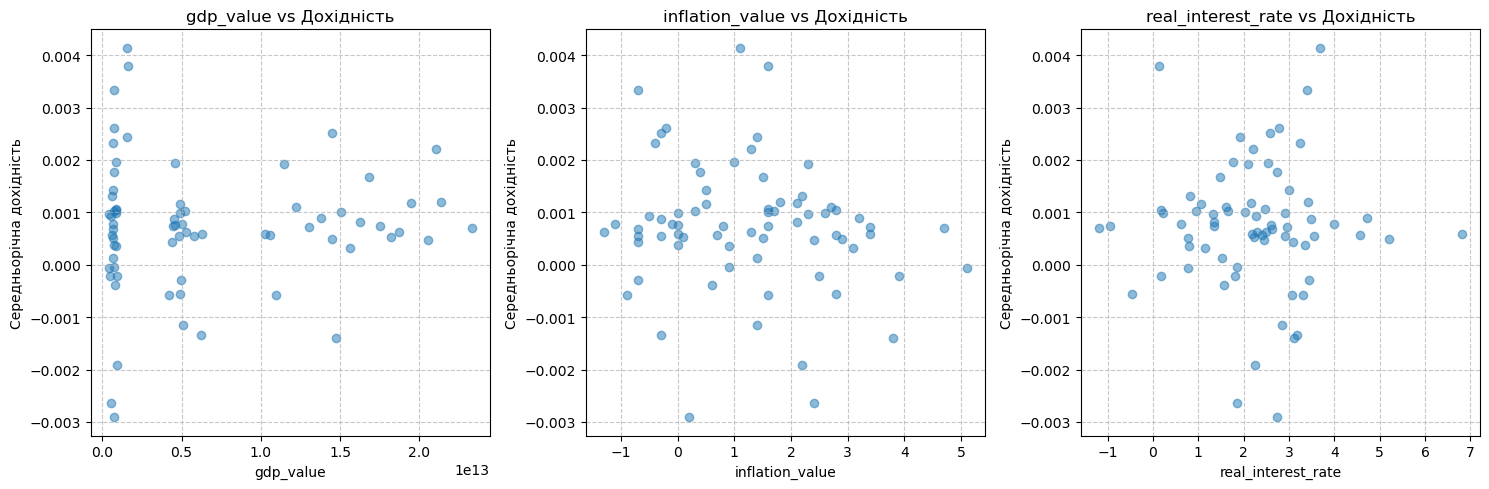

In [33]:
# Діаграми розсіювання
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(['gdp_value', 'inflation_value', 'real_interest_rate']):
    ax = axes[idx]
    ax.scatter(df_corr[col], df_corr['avg_daily_return_stocks'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Середньорічна дохідність')
    ax.set_title(f'{col} vs Дохідність')
    ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<p>Кореляційний аналіз не виявив статистично значущого лінійного зв'язку між досліджуваними макроекономічними факторами та дохідністю акцій Коефіцієнт кореляції Пірсона між ВВП та дохідністю становив 0.0455 (p=0.71), між інфляцією та дохідністю становить -0.1580 (p=0.19), між реальними процентними ставками та дохідністю становить -0.0040 (p=0.97). Жоден з цих зв'язків не є статистично значущим на рівні p=0.05.</p>
<p>Цей результат не є несподіваним. Відповідно до гіпотези ефективного ринку, вся публічно доступна інформація, включаючи макроекономічні показники, вже відображена в поточних цінах активів. Тому пряма лінійна залежність між річними макроекономічними показниками та дохідністю може бути відсутньою. Однак відсутність лінійного зв'язку не виключає наявності більш складних, нелінійних залежностей. Для їх виявлення було застосовано методи машинного навчання.</p>

<p>Також використаємо датасет stocks_analysis_with_unemployment для виявлення кореляції між дохідністю акцій та рівнем безробіття</p>

In [34]:
df_corr = stocks_analysis_with_unemployment.copy()

# Вибір числових колонок для аналізу
numeric_cols = ['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value', 'avg_daily_return_stocks']
df_numeric = df_corr[numeric_cols]

# Обчислення кореляційної матриці
corr_matrix = df_numeric.corr()
print("Кореляційна матриця:")
corr_matrix.round(4)

Кореляційна матриця:


,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_stocks
gdp_value,1.00000000,0.60470000,-0.14940000,0.19250000,-0.23080000
inflation_value,0.60470000,1.00000000,-0.57190000,0.13270000,-0.17130000
real_interest_rate,-0.14940000,-0.57190000,1.00000000,0.21900000,0.29080000
unemployment_rate_value,0.19250000,0.13270000,0.21900000,1.00000000,0.48430000
avg_daily_return_stocks,-0.23080000,-0.17130000,0.29080000,0.48430000,1.00000000


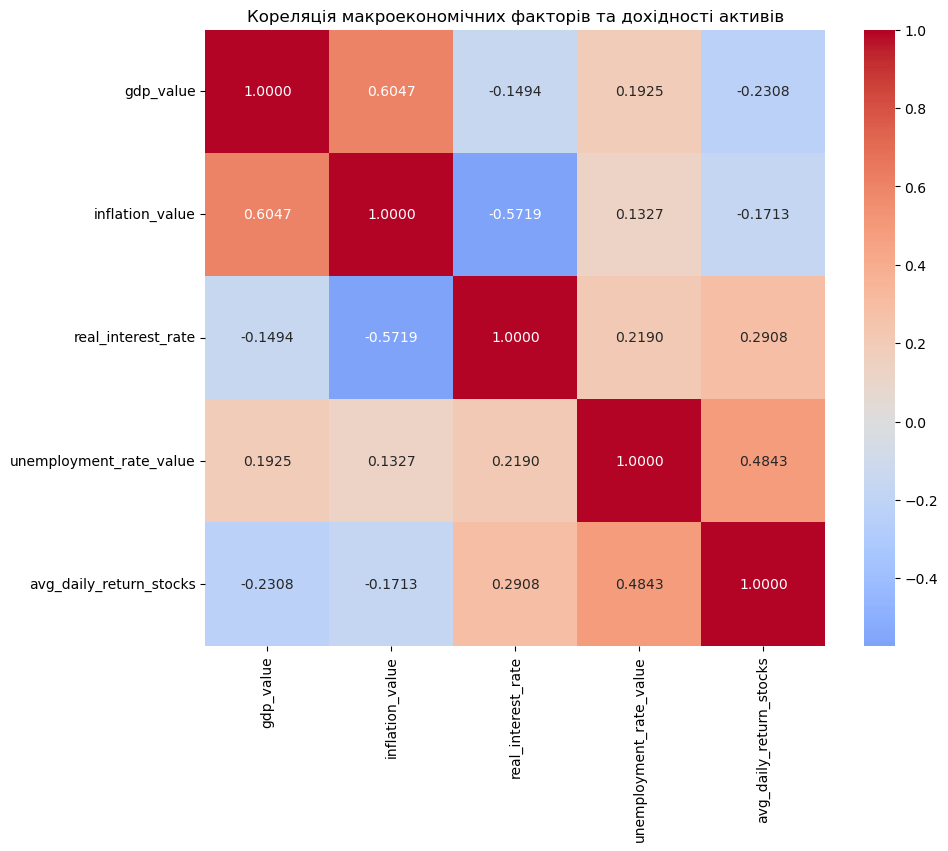

In [35]:
# Візуалізація теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.4f')
plt.title('Кореляція макроекономічних факторів та дохідності активів')
plt.show()

<p>З матриці видно, що найсильніший зв'язок з дохідністю акцій має рівень безробіття (r = 0.4843), і ця кореляція є статистично значущою (p = 0.0192). Інші фактори показують слабкі та незначущі зв'язки. <strong>Це свідчить, що на обмеженому періоді 2014-2021 років безробіття є найбільш інформативним макроекономічним індикатором для акцій.</strong></p>

In [36]:
# Перевірка статистичної значущості кореляції для кожної пари
print("Перевірка статистичної значущості:")
for col in ['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']:
    # Видаляємо рядки з пропущеними значеннями для коректного розрахунку
    clean_data = df_corr[[col, 'avg_daily_return_stocks']].dropna()
    pearson_coef, p_value = stats.pearsonr(clean_data[col], clean_data['avg_daily_return_stocks'])
    print(f"\n{col} vs avg_daily_return_stocks:")
    print(f" Коефіцієнт Пірсона = {pearson_coef:.4f}")
    print(f" p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f" - Кореляція статистично значуща (p < 0.05)")
    else:
        print(f" - Кореляція НЕ статистично значуща (p > 0.05)")

Перевірка статистичної значущості:

gdp_value vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = -0.2308
 p-value = 0.2895
 - Кореляція НЕ статистично значуща (p > 0.05)

inflation_value vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = -0.1713
 p-value = 0.4345
 - Кореляція НЕ статистично значуща (p > 0.05)

real_interest_rate vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = 0.2908
 p-value = 0.1783
 - Кореляція НЕ статистично значуща (p > 0.05)

unemployment_rate_value vs avg_daily_return_stocks:
 Коефіцієнт Пірсона = 0.4843
 p-value = 0.0192
 - Кореляція статистично значуща (p < 0.05)


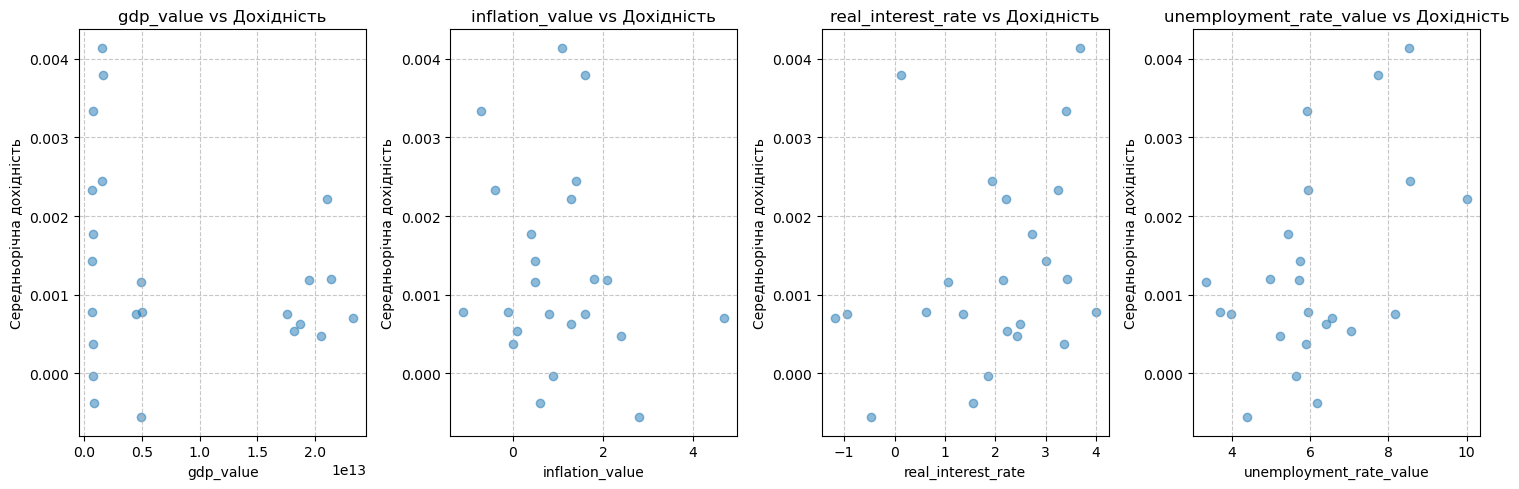

In [37]:
# Діаграми розсіювання
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for idx, col in enumerate(['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']):
    ax = axes[idx]
    ax.scatter(df_corr[col], df_corr['avg_daily_return_stocks'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Середньорічна дохідність')
    ax.set_title(f'{col} vs Дохідність')
    ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<p>На діаграмах розсіювання видно, що точки для безробіття утворюють помітний висхідний патерн, тоді як для ВВП, інфляції та процентних ставок точки розкидані хаотично. <strong>Це візуально підтверджує наявність позитивного зв'язку між рівнем безробіття та дохідністю акцій, виявленого кореляційним аналізом</strong></p>

<h4>Кореляційний аналіз для криптовалют</h4>

<p>Спробуємо використати crypto_analysis_no_unemployment, оскільки там більше даних</p>

In [38]:
df_corr_crypto = crypto_analysis_no_unemployment.copy()
numeric_cols_crypto = ['gdp_value', 'inflation_value', 'real_interest_rate', 'avg_daily_return_crypto']
corr_matrix_crypto = df_corr_crypto[numeric_cols_crypto].corr()
print("Кореляційна матриця для криптовалют:")
corr_matrix_crypto.round(4)

Кореляційна матриця для криптовалют:


,gdp_value,inflation_value,real_interest_rate,avg_daily_return_crypto
gdp_value,1.00000000,0.76100000,-0.42050000,0.77430000
inflation_value,0.76100000,1.00000000,-0.74910000,0.84750000
real_interest_rate,-0.42050000,-0.74910000,1.00000000,-0.86640000
avg_daily_return_crypto,0.77430000,0.84750000,-0.86640000,1.00000000


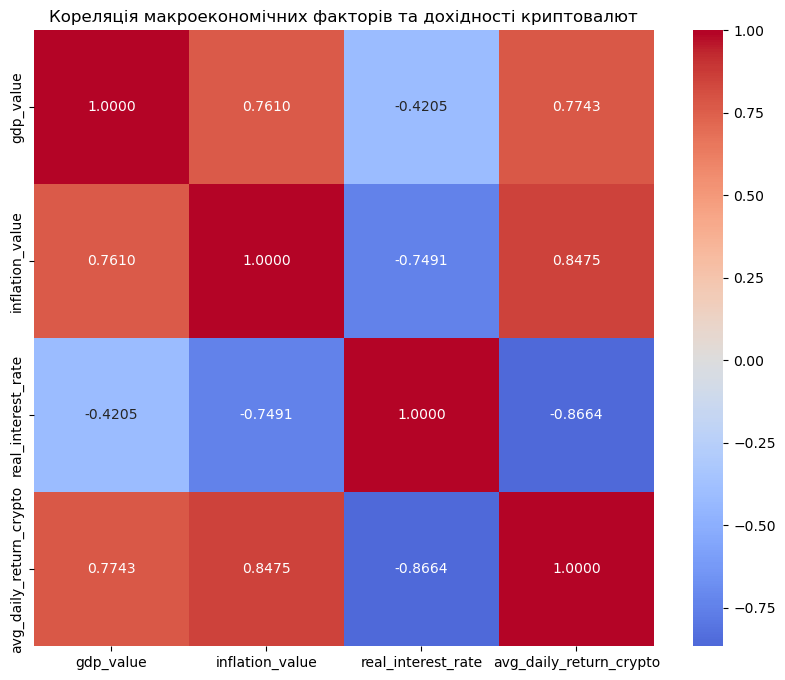

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_crypto, annot=True, cmap='coolwarm', center=0, fmt='.4f')
plt.title('Кореляція макроекономічних факторів та дохідності криптовалют')
plt.show()

<p>З матриці видно дуже сильні кореляційні зв'язки між всіма макрофакторами та дохідністю криптовалют. Найсильніший зв'язок - з реальною процентною ставкою (r = -0.8664), потім з інфляцією (r = 0.8475) та ВВП (r = 0.7743). Всі ці зв'язки є статистично значущими (p < 0.05), що <strong>вказує на чутливість крипторинку до макроекономічних умов США</strong></p>

In [40]:
print("Перевірка статистичної значущості (криптовалюти):")
for col in ['gdp_value', 'inflation_value', 'real_interest_rate']:
    clean_data_crypto = df_corr_crypto[[col, 'avg_daily_return_crypto']].dropna()
    pearson_coef, p_value = stats.pearsonr(clean_data_crypto[col], clean_data_crypto['avg_daily_return_crypto'])
    print(f"\n{col} vs avg_daily_return_crypto:")
    print(f" Коефіцієнт Пірсона = {pearson_coef:.4f}")
    print(f" p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f" - Кореляція статистично значуща (p < 0.05)")
    else:
        print(f" - Кореляція НЕ статистично значуща (p > 0.05)")

Перевірка статистичної значущості (криптовалюти):

gdp_value vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = 0.7743
 p-value = 0.0241
 - Кореляція статистично значуща (p < 0.05)

inflation_value vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = 0.8475
 p-value = 0.0079
 - Кореляція статистично значуща (p < 0.05)

real_interest_rate vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = -0.8664
 p-value = 0.0054
 - Кореляція статистично значуща (p < 0.05)


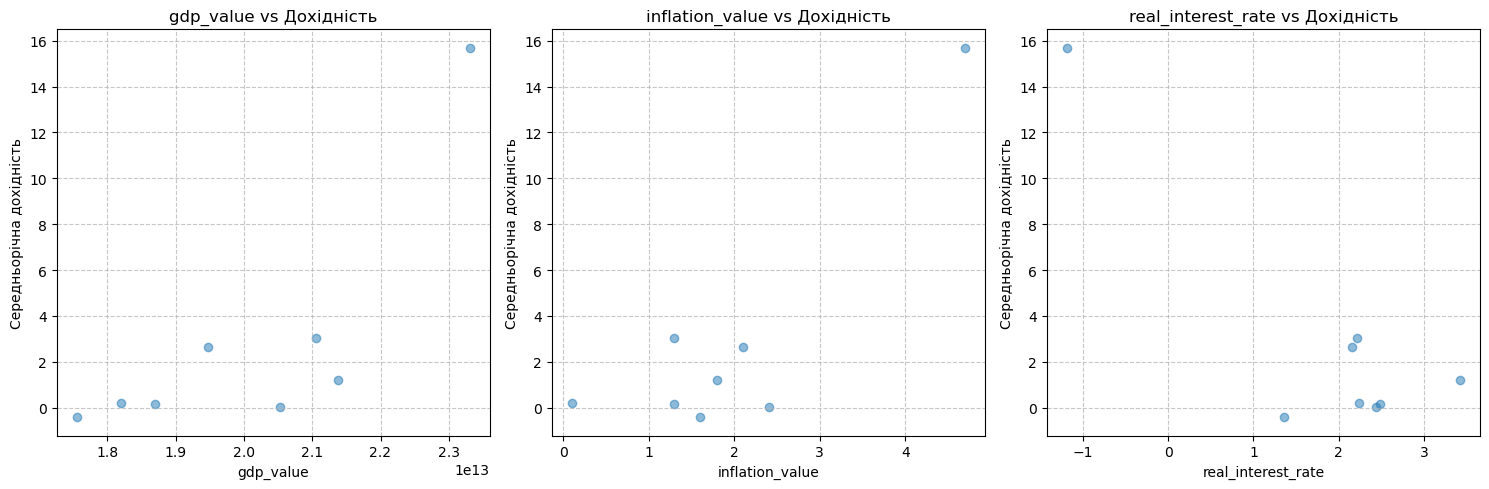

In [41]:
# Діаграми розсіювання
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(['gdp_value', 'inflation_value', 'real_interest_rate']):
    ax = axes[idx]
    ax.scatter(df_corr_crypto[col], df_corr_crypto['avg_daily_return_crypto'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Середньорічна дохідність')
    ax.set_title(f'{col} vs Дохідність')
    ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<p>Діаграми розсіювання для криптовалют демонструють чіткі лінійні залежності: зі зростанням ВВП та інфляції дохідність зростає, а зі зростанням реальної процентної ставки - падає. Точки помітно групуються вздовж уявних прямих ліній, що візуально підтверджує кореляцію. Викидів, які б суттєво спотворювали картину, не спостерігається.</p>

<p>Також використаємо датасет crypto_analysis_with_unemployment для виявлення кореляції між дохідністю криптовалют та рівнем безробіття</p>

In [42]:
df_corr_crypto = crypto_analysis_with_unemployment.copy()
numeric_cols_crypto = ['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value', 'avg_daily_return_crypto']
corr_matrix_crypto = df_corr_crypto[numeric_cols_crypto].corr()
print("Кореляційна матриця для криптовалют:")
corr_matrix_crypto.round(4)

Кореляційна матриця для криптовалют:


,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_crypto
gdp_value,1.00000000,0.76100000,-0.42050000,-0.15480000,0.77430000
inflation_value,0.76100000,1.00000000,-0.74910000,-0.26100000,0.84750000
real_interest_rate,-0.42050000,-0.74910000,1.00000000,-0.19330000,-0.86640000
unemployment_rate_value,-0.15480000,-0.26100000,-0.19330000,1.00000000,0.01870000
avg_daily_return_crypto,0.77430000,0.84750000,-0.86640000,0.01870000,1.00000000


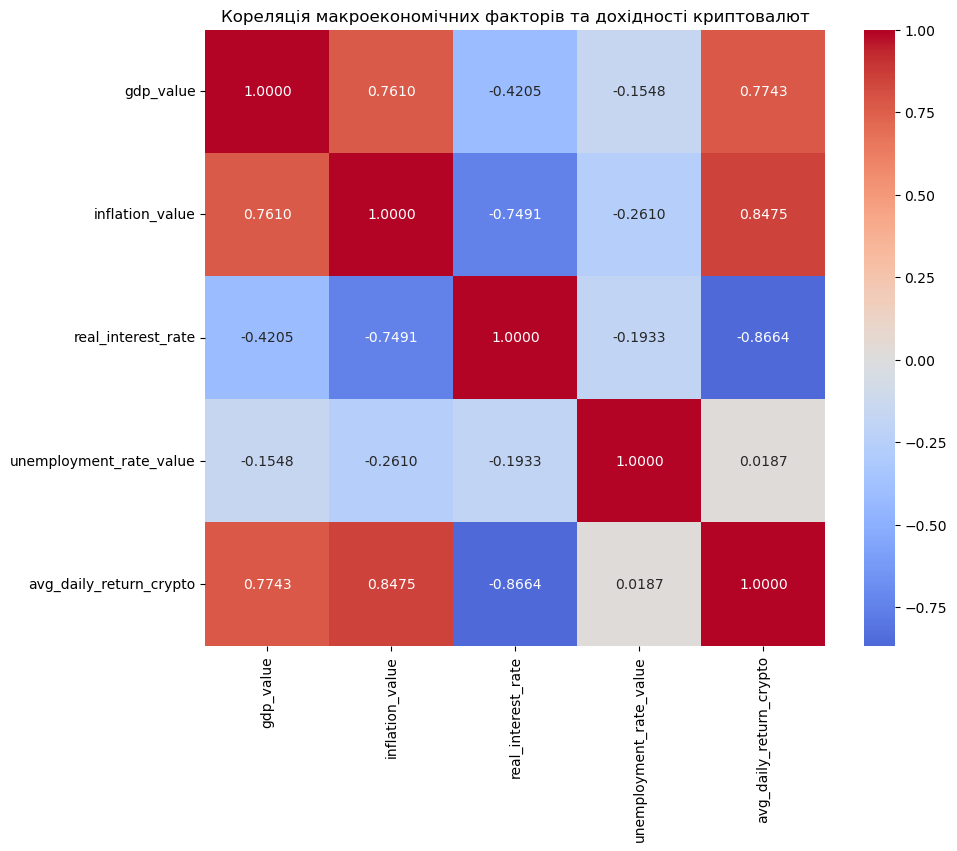

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_crypto, annot=True, cmap='coolwarm', center=0, fmt='.4f')
plt.title('Кореляція макроекономічних факторів та дохідності криптовалют')
plt.show()

<p>З матриці видно, що зв'язки з ВВП, інфляцією та реальною процентною ставкою залишаються сильними та значущими. Однак кореляція з рівнем безробіття виявилась практично відсутньою (r = 0.0187). Це означає, що криптовалюти реагують на загальну макроекономічну ситуацію, але не на стан ринку праці.</p>

In [44]:
print("Перевірка статистичної значущості (криптовалюти з безробіттям):")
for col in ['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']:
    clean_data_crypto = df_corr_crypto[[col, 'avg_daily_return_crypto']].dropna()
    pearson_coef, p_value = stats.pearsonr(clean_data_crypto[col], clean_data_crypto['avg_daily_return_crypto'])
    print(f"\n{col} vs avg_daily_return_crypto:")
    print(f" Коефіцієнт Пірсона = {pearson_coef:.4f}")
    print(f" p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f" - Кореляція статистично значуща (p < 0.05)")
    else:
        print(f" - Кореляція НЕ статистично значуща (p > 0.05)")

Перевірка статистичної значущості (криптовалюти з безробіттям):

gdp_value vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = 0.7743
 p-value = 0.0241
 - Кореляція статистично значуща (p < 0.05)

inflation_value vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = 0.8475
 p-value = 0.0079
 - Кореляція статистично значуща (p < 0.05)

real_interest_rate vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = -0.8664
 p-value = 0.0054
 - Кореляція статистично значуща (p < 0.05)

unemployment_rate_value vs avg_daily_return_crypto:
 Коефіцієнт Пірсона = 0.0187
 p-value = 0.9649
 - Кореляція НЕ статистично значуща (p > 0.05)


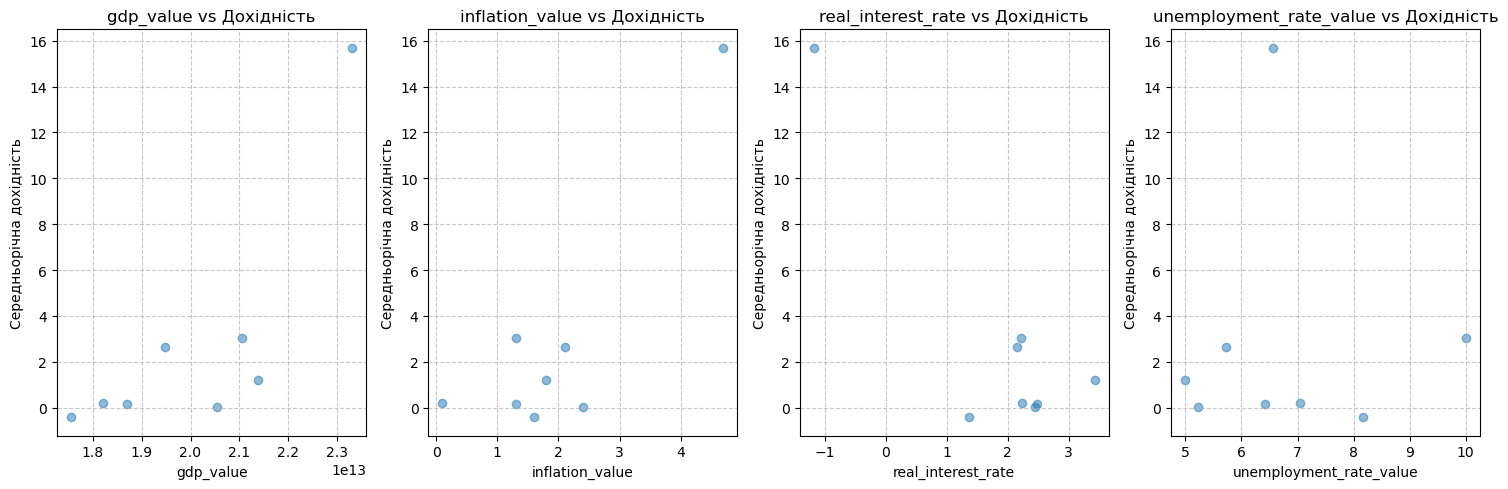

In [45]:
# Діаграми розсіювання
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for idx, col in enumerate(['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']):
    ax = axes[idx]
    ax.scatter(df_corr_crypto[col], df_corr_crypto['avg_daily_return_crypto'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Середньорічна дохідність')
    ax.set_title(f'{col} vs Дохідність')
    ax.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<p>Діаграми розсіювання для криптовалют демонструють чіткі лінійні залежності: зі зростанням ВВП та інфляції дохідність зростає, а зі зростанням реальної процентної ставки - падає. Більшість точок щільно групуються вздовж уявних прямих, хоча присутній один помітний викид (точка з високою дохідністю)</p>

<p>Кореляційний аналіз показав, що для акцій статистично значущий зв'язок виявлено лише з рівнем безробіття на періоді 2014-2021 років. <strong>Для криптовалют виявлено сильні статистично значущі зв'язки з ВВП, інфляцією та реальною процентною ставкою, але зв'язок з безробіттям відсутній.</strong> Це підтверджує, що криптовалюти є більш чутливими до макроекономічних умов, ніж акції</p>

<h2>3. Побудова регресійних моделей для прогнозування дохідності</h2>

<p>Побудова лінійної, множинної та поліноміальної регресій для прогнозування дохідності активів на основі макроекономічних факторів.</p>

<h4>Побудова регресійних моделей для прогнозування дохідності акцій</h4>

In [46]:
# Використовуємо stocks_analysis_no_unemployment
df_reg = stocks_analysis_no_unemployment.copy()

# Визначення предикторів та цільової змінної
X = df_reg[['gdp_value', 'inflation_value', 'real_interest_rate']]
y = df_reg['avg_daily_return_stocks']


print("ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ")
for col in X.columns:
    lr = LinearRegression()
    # Беремо тільки одну колонку для навчання
    lr.fit(df_reg[[col]], y)  
    y_pred = lr.predict(df_reg[[col]])
    r2_linear = r2_score(y, y_pred)
    mae_linear = mean_absolute_error(y, y_pred)
    rmse_linear = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"\n{col}:")
    print(f"Рівняння: daily_return = {lr.intercept_:.6f} + {lr.coef_[0]:.6f} * {col}")
    print(f"R^2 = {r2_linear:.6f}")
    print(f"MAE = {mae_linear:.6f}")
    print(f"RMSE = {rmse_linear:.6f}")

ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ

gdp_value:
Рівняння: daily_return = 0.000674 + 0.000000 * gdp_value
R^2 = 0.002071
MAE = 0.000829
RMSE = 0.001223

inflation_value:
Рівняння: daily_return = 0.000892 + -0.000133 * inflation_value
R^2 = 0.024964
MAE = 0.000843
RMSE = 0.001209

real_interest_rate:
Рівняння: daily_return = 0.000735 + -0.000004 * real_interest_rate
R^2 = 0.000016
MAE = 0.000825
RMSE = 0.001224


<p>Результати одномірної лінійної регресії показали, що окремо жоден макроекономічний показник не може передбачити дохідність акцій. Коефіцієнт детермінації R^2 для ВВП становить 0.002 (0.2%), для інфляції - 0.025 (2.5%), для реальної процентної ставки - 0.000016 (0.0016%). Це означає, що моделі пояснюють менше 3% варіації дохідності. Найкращий результат показала модель з інфляцією, але її прогностична здатність все одно дуже низька. Використовувати ці показники окремо для прогнозу дохідності акцій недоцільно.</p>

In [47]:
print("МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ")

lr_multiple = LinearRegression()
lr_multiple.fit(X, y)
y_pred_multiple = lr_multiple.predict(X)

print(f"Рівняння: daily_return = {lr_multiple.intercept_:.6f}")
for i, col in enumerate(X.columns):
    print(f" + {lr_multiple.coef_[i]:.6f} * {col}")
    
r2_multiple = r2_score(y, y_pred_multiple)
mse_multiple = mean_squared_error(y, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
mae_multiple = mean_absolute_error(y, y_pred_multiple)

print(f"R^2 = {r2_multiple:.6f}")
print(f"MSE = {mse_multiple:.6f}")
print(f"RMSE = {rmse_multiple:.6f}")
print(f"MAE = {mae_multiple:.6f}")


МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ
Рівняння: daily_return = 0.000955
 + 0.000000 * gdp_value
 + -0.000184 * inflation_value
 + -0.000066 * real_interest_rate
R^2 = 0.040417
MSE = 0.000001
RMSE = 0.001199
MAE = 0.000838


<p>Коли використали всі три показники разом, R^2 становить 0.040417 (4.04%). Це краще, ніж одномірні лінійні моделі, але все ще дуже мало. Знаки коефіцієнтів збігаються з економічною теорією: чим вища інфляція та процентні ставки, тим нижча дохідність. ВВП, як і раніше, майже не впливає.</p>

In [48]:
print("ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2)")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)
y_pred_poly = lr_poly.predict(X_poly)

print(f"Кількість ознак після поліноміального перетворення: {X_poly.shape[1]}")
r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)

print(f"R^2 = {r2_poly:.6f}")
print(f"MSE = {mse_poly:.6f}")
print(f"RMSE = {rmse_poly:.6f}")
print(f"MAE = {mae_poly:.6f}")

ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2)
Кількість ознак після поліноміального перетворення: 9
R^2 = 0.032835
MSE = 0.000001
RMSE = 0.001204
MAE = 0.000831


<p>Поліноміальна регресія другого ступеня показала R^2 = 0.032835 (3.28%), що навіть трохи гірше за звичайну множинну регресію. Це може бути пов'язано з невеликим обсягом даних (71 спостереження) - після додавання нелінійних членів кількість ознак зросла до 9, що ускладнило навчання моделі.</p>

In [49]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Multiple Regression",
        "Polynomial Regression"
    ],
    "R2": [
        r2_linear,
        r2_multiple,
        r2_poly
    ],
    "MAE": [
        mae_linear,
        mae_multiple,
        mae_poly
    ],
    "RMSE": [
        rmse_linear,
        rmse_multiple,
        rmse_poly
    ]
})

comparison_df = comparison_df.sort_values("R2", ascending=False)

comparison_df

,Model,R2,MAE,RMSE
1,Multiple Regression,0.04041746,0.00083763,0.00119906
2,Polynomial Regression,0.03283536,0.00083104,0.00120378
0,Linear Regression,0.00001587,0.00082525,0.00122404


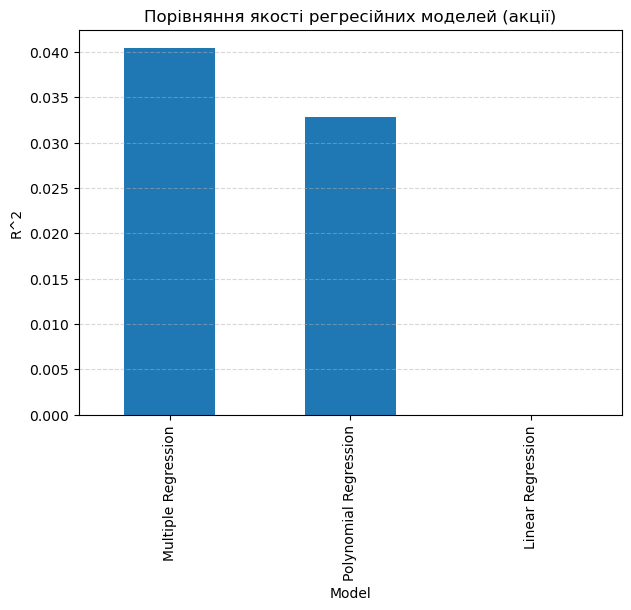

In [50]:
comparison_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("R^2")
plt.title("Порівняння якості регресійних моделей (акції)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p> Найкращою моделлю для stocks_analysis_no_unemployment виявилась <strong>множинна лінійна регресія</strong> </p>

In [51]:
# Використовуємо stocks_analysis_with_unemployment
df_reg = stocks_analysis_with_unemployment.copy()

# Визначення предикторів та цільової змінної
X = df_reg[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y = df_reg['avg_daily_return_stocks']


print("ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ")
for col in X.columns:
    lr = LinearRegression()
    # Беремо тільки одну колонку для навчання
    lr.fit(df_reg[[col]], y)  
    y_pred = lr.predict(df_reg[[col]])
    r2_linear = r2_score(y, y_pred)
    mae_linear = mean_absolute_error(y, y_pred)
    rmse_linear = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"\n{col}:")
    print(f"Рівняння: daily_return = {lr.intercept_:.6f} + {lr.coef_[0]:.6f} * {col}")
    print(f"R^2 = {r2_linear:.6f}")
    print(f"MAE = {mae_linear:.6f}")
    print(f"RMSE = {rmse_linear:.6f}")

ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ

gdp_value:
Рівняння: daily_return = 0.001560 + -0.000000 * gdp_value
R^2 = 0.053248
MAE = 0.000919
RMSE = 0.001184

inflation_value:
Рівняння: daily_return = 0.001468 + -0.000169 * inflation_value
R^2 = 0.029349
MAE = 0.000932
RMSE = 0.001199

real_interest_rate:
Рівняння: daily_return = 0.000824 + 0.000245 * real_interest_rate
R^2 = 0.084553
MAE = 0.000905
RMSE = 0.001164

unemployment_rate_value:
Рівняння: daily_return = -0.000962 + 0.000368 * unemployment_rate_value
R^2 = 0.234535
MAE = 0.000890
RMSE = 0.001064


<p>Результати одномірної лінійної регресії stocks_analysis_with_unemployment Результати одномірної лінійної регресії показали, що рівень безробіття окремо пояснює 23.45% варіації дохідності акцій (R^2 = 0.234535), що значно більше за інші фактори (R^2 = 0.084553 для ставок, 0.029349 для інфляції, 0.053248 для ВВП). <strong> Це підтверджує, що на обмеженому періоді 2014-2021 років безробіття є найбільш інформативним фактором для прогнозування дохідності акцій.</strong></p>

In [52]:
print("МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ")

lr_multiple = LinearRegression()
lr_multiple.fit(X, y)
y_pred_multiple = lr_multiple.predict(X)

print(f"Рівняння: daily_return = {lr_multiple.intercept_:.6f}")
for i, col in enumerate(X.columns):
    print(f" + {lr_multiple.coef_[i]:.6f} * {col}")
r2_multiple = r2_score(y, y_pred_multiple)
mse_multiple = mean_squared_error(y, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
mae_multiple = mean_absolute_error(y, y_pred_multiple)

print(f"R^2 = {r2_multiple:.6f}")
print(f"MSE = {mse_multiple:.6f}")
print(f"RMSE = {rmse_multiple:.6f}")
print(f"MAE = {mae_multiple:.6f}")


МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ
Рівняння: daily_return = -0.001000
 + -0.000000 * gdp_value
 + 0.000061 * inflation_value
 + 0.000138 * real_interest_rate
 + 0.000384 * unemployment_rate_value
R^2 = 0.360787
MSE = 0.000001
RMSE = 0.000973
MAE = 0.000788


<p>Множинна лінійна регресія stocks_analysis_with_unemployment з чотирма факторами досягла R^2 = 0.360787, що пояснює 36.0% варіації дохідності акцій. Це значно кращий результат, ніж в Аналізі 1 для stocks_analysis_no_unemployment (R^2 = 0.040417), що свідчить про важливість врахування безробіття. <strong>Коефіцієнт при безробітті є найбільшим (0.000384) та позитивним, що вказує на зростання дохідності при збільшенні безробіття. </strong></p>

In [53]:
print("ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2)")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)
y_pred_poly = lr_poly.predict(X_poly)

print(f"Кількість ознак після поліноміального перетворення: {X_poly.shape[1]}")
r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)

print(f"R^2 = {r2_poly:.6f}")
print(f"MSE = {mse_poly:.6f}")
print(f"RMSE = {rmse_poly:.6f}")
print(f"MAE = {mae_poly:.6f}")

ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2)
Кількість ознак після поліноміального перетворення: 14
R^2 = 0.204025
MSE = 0.000001
RMSE = 0.001085
MAE = 0.000798


<p>Поліноміальна регресія stocks_analysis_with_unemployment другого ступеня показала R^2 = 0.204025, що гірше за звичайну множинну регресію (R^2 = 0.360787). Це свідчить про відсутність нелінійних ефектів у залежності дохідності акцій від макроекономічних факторів на даному періоді. Лінійна модель є достатньою для опису зв'язків.</p>

In [54]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Multiple Regression",
        "Polynomial Regression"
    ],
    "R2": [
        r2_linear,
        r2_multiple,
        r2_poly
    ],
    "MAE": [
        mae_linear,
        mae_multiple,
        mae_poly
    ],
    "RMSE": [
        rmse_linear,
        rmse_multiple,
        rmse_poly
    ]
})

comparison_df = comparison_df.sort_values("R2", ascending=False)

comparison_df

,Model,R2,MAE,RMSE
1,Multiple Regression,0.36078746,0.00078832,0.00097270
0,Linear Regression,0.23453499,0.00089012,0.00106444
2,Polynomial Regression,0.20402465,0.00079827,0.00108544


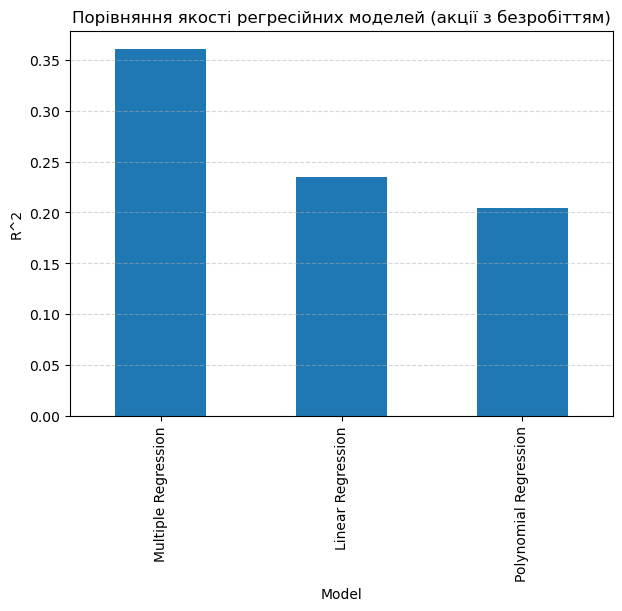

In [55]:
comparison_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("R^2")
plt.title("Порівняння якості регресійних моделей (акції з безробіттям)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p> Найкращою моделлю для stocks_analysis_no_unemployment виявилась <strong>множинна лінійна регресія</strong> </p>

<h4>Побудова регресійних моделей для прогнозування дохідності криптовалют</h4>

In [56]:
df_reg_crypto = crypto_analysis_no_unemployment.copy()
X_crypto = df_reg_crypto[['gdp_value', 'inflation_value', 'real_interest_rate']]
y_crypto = df_reg_crypto['avg_daily_return_crypto']

print("ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):")
for col in X_crypto.columns:
    lr_crypto = LinearRegression()
    lr_crypto.fit(df_reg_crypto[[col]], y_crypto)
    y_pred_crypto = lr_crypto.predict(df_reg_crypto[[col]])
    r2 = r2_score(y_crypto, y_pred_crypto)
    mae = mean_absolute_error(y_crypto, y_pred_crypto)
    mse = mean_squared_error(y_crypto, y_pred_crypto)
    rmse = np.sqrt(mse)

    print(f"\n{col}")
    print(f"R^2 = {r2:.6f}")
    print(f"MAE = {mae:.6f}")
    print(f"MSE = {mse:.6f}")
    print(f"RMSE = {rmse:.6f}")

ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):

gdp_value
R^2 = 0.599488
MAE = 2.617101
MSE = 10.030863
RMSE = 3.167154

inflation_value
R^2 = 0.718341
MAE = 2.305751
MSE = 7.054192
RMSE = 2.655973

real_interest_rate
R^2 = 0.750652
MAE = 2.014667
MSE = 6.244956
RMSE = 2.498991


<p>Одномірна лінійна регресія crypto_analysis_no_unemployment для криптовалют показала дуже високі значення R^2: для реальної процентної ставки 0.750652, для інфляції 0.718341, для ВВП 0.599488. Це означає, що кожен фактор окремо пояснює 60-75% варіації дохідності криптовалют. Найкращою виявилась модель з реальною процентною ставкою.</p>

In [57]:
print("МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):")
lr_multiple_crypto = LinearRegression()
lr_multiple_crypto.fit(X_crypto, y_crypto)
y_pred_multiple_crypto = lr_multiple_crypto.predict(X_crypto)

print(f"Рівняння: daily_return = {lr_multiple_crypto.intercept_:.6f}")
for i, col in enumerate(X_crypto.columns):
    print(f" + {lr_multiple_crypto.coef_[i]:.6f} * {col}")
r2_multiple = r2_score(y_crypto, y_pred_multiple_crypto)
mae_multiple = mean_absolute_error(y_crypto, y_pred_multiple_crypto)
mse_multiple = mean_squared_error(y_crypto, y_pred_multiple_crypto)
rmse_multiple = np.sqrt(mse_multiple)

print(f"R^2 = {r2_multiple:.6f}")
print(f"MAE = {mae_multiple:.6f}")
print(f"MSE = {mse_multiple:.6f}")
print(f"RMSE = {rmse_multiple:.6f}")

МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):
Рівняння: daily_return = -22.532068
 + 0.000000 * gdp_value
 + -0.485826 * inflation_value
 + -2.815596 * real_interest_rate
R^2 = 0.957668
MAE = 0.901319
MSE = 1.060203
RMSE = 1.029662


<p>Множинна лінійна регресія crypto_analysis_no_unemployment для криптовалют досягла R^2 = 0.957668, пояснюючи майже 96% варіації дохідності. Це значно більше, ніж показники одномірних моделей (найкраща з яких давала 75%), тому що разом три фактори доповнюють один одного. Макроекономічні фактори є основними рушіями ціноутворення на ринку криптовалют.</p>

In [58]:
print("ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2) для криптовалют:")
poly_crypto = PolynomialFeatures(degree=2, include_bias=False)
X_poly_crypto = poly_crypto.fit_transform(X_crypto)
lr_poly_crypto = LinearRegression()
lr_poly_crypto.fit(X_poly_crypto, y_crypto)
y_pred_poly_crypto = lr_poly_crypto.predict(X_poly_crypto)
r2_poly = r2_score(y_crypto, y_pred_poly_crypto)
mae_poly = mean_absolute_error(y_crypto, y_pred_poly_crypto)
mse_poly = mean_squared_error(y_crypto, y_pred_poly_crypto)
rmse_poly = np.sqrt(mse_poly)

print(f"R^2 = {r2_poly:.6f}")
print(f"MAE = {mae_poly:.6f}")
print(f"MSE = {mse_poly:.6f}")
print(f"RMSE = {rmse_poly:.6f}")

ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2) для криптовалют:
R^2 = 0.963373
MAE = 0.797559
MSE = 0.917333
RMSE = 0.957775


<p>Поліноміальна регресія crypto_analysis_no_unemployment другого ступеня досягла R^2 = 0.963373, що лише незначно краще за множинну лінійну регресію (R^2 = 0.957668). Враховуючи малий обсяг даних (8 спостережень), додавання нелінійних членів не дає суттєвого виграшу. Тому множинна лінійна регресія є оптимальним вибором.</p>

In [59]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Multiple Regression",
        "Polynomial Regression"
    ],
    "R2": [
        r2,
        r2_multiple,
        r2_poly
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly
    ]
})

comparison_df = comparison_df.sort_values("R2", ascending=False)

comparison_df

,Model,R2,MAE,RMSE
2,Polynomial Regression,0.96337282,0.79755884,0.95777477
1,Multiple Regression,0.95766830,0.90131871,1.02966153
0,Linear Regression,0.75065187,2.01466748,2.49899094


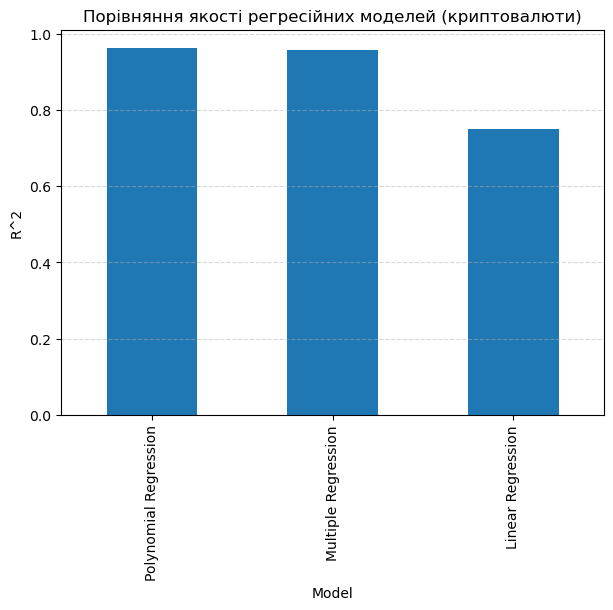

In [60]:
comparison_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("R^2")
plt.title("Порівняння якості регресійних моделей (криптовалюти)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p>Найкращою для датасету crypto_analysis_no_unemployment виявилась поліноміальна регресія другого ступеня з R^2 = 0.963373, яка пояснює 96.3% варіації дохідності криптовалют.</p>

In [61]:
df_reg_crypto = crypto_analysis_with_unemployment.copy()
X_crypto = df_reg_crypto[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y_crypto = df_reg_crypto['avg_daily_return_crypto']

print("ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):")
for col in X_crypto.columns:
    lr_crypto = LinearRegression()
    lr_crypto.fit(df_reg_crypto[[col]], y_crypto)
    y_pred_crypto = lr_crypto.predict(df_reg_crypto[[col]])
    r2 = r2_score(y_crypto, y_pred_crypto)
    mae = mean_absolute_error(y_crypto, y_pred_crypto)
    mse = mean_squared_error(y_crypto, y_pred_crypto)
    rmse = np.sqrt(mse)

    print(f"\n{col}")
    print(f"R^2 = {r2:.6f}")
    print(f"MAE = {mae:.6f}")
    print(f"MSE = {mse:.6f}")
    print(f"RMSE = {rmse:.6f}")

ОДНОМІРНА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):

gdp_value
R^2 = 0.599488
MAE = 2.617101
MSE = 10.030863
RMSE = 3.167154

inflation_value
R^2 = 0.718341
MAE = 2.305751
MSE = 7.054192
RMSE = 2.655973

real_interest_rate
R^2 = 0.750652
MAE = 2.014667
MSE = 6.244956
RMSE = 2.498991

unemployment_rate_value
R^2 = 0.000350
MAE = 3.225790
MSE = 25.036359
RMSE = 5.003635


<p>Результати одномірної лінійної регресії crypto_analysis_with_unemployment для криптовалют з безробіттям показали, що безробіття практично не впливає на дохідність (R^2 = 0.000350). Зв'язки з ВВП, інфляцією та реальною процентною ставкою залишаються сильними (R^2 = 0.599488-0.750652). Додавання безробіття не покращує прогностичну здатність одномірних моделей.</p>

In [62]:
print("МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):")
lr_multiple_crypto = LinearRegression()
lr_multiple_crypto.fit(X_crypto, y_crypto)
y_pred_multiple_crypto = lr_multiple_crypto.predict(X_crypto)
r2_multiple = r2_score(y_crypto, y_pred_multiple_crypto)
mae_multiple = mean_absolute_error(y_crypto, y_pred_multiple_crypto)
mse_multiple = mean_squared_error(y_crypto, y_pred_multiple_crypto)
rmse_multiple = np.sqrt(mse_multiple)

print(f"R^2 = {r2_multiple:.6f}")
print(f"MAE = {mae_multiple:.6f}")
print(f"MSE = {mse_multiple:.6f}")
print(f"RMSE = {rmse_multiple:.6f}")

МНОЖИННА ЛІНІЙНА РЕГРЕСІЯ (криптовалюти):
R^2 = 0.965922
MAE = 0.687239
MSE = 0.853492
RMSE = 0.923847


<p>Результати множинної лінійної регресії  Множинна лінійна регресія crypto_analysis_with_unemployment з чотирма факторами досягла R^2 = 0.965922, що практично ідентично моделі без безробіття (R^2 = 0.957668). Коефіцієнт при безробітті виявився дуже малим, що підтверджує відсутність впливу цього фактору. Включення безробіття не дає жодного покращення прогнозу.</p>

In [63]:
print("ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2) для криптовалют:")
poly_crypto = PolynomialFeatures(degree=2, include_bias=False)
X_poly_crypto = poly_crypto.fit_transform(X_crypto)
lr_poly_crypto = LinearRegression()
lr_poly_crypto.fit(X_poly_crypto, y_crypto)
y_pred_poly_crypto = lr_poly_crypto.predict(X_poly_crypto)
r2_poly = r2_score(y_crypto, y_pred_poly_crypto)
mae_poly = mean_absolute_error(y_crypto, y_pred_poly_crypto)
mse_poly = mean_squared_error(y_crypto, y_pred_poly_crypto)
rmse_poly = np.sqrt(mse_poly)

print(f"R^2 = {r2_poly:.6f}")
print(f"MAE = {mae_poly:.6f}")
print(f"MSE = {mse_poly:.6f}")
print(f"RMSE = {rmse_poly:.6f}")

ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (degree=2) для криптовалют:
R^2 = 0.968375
MAE = 0.645960
MSE = 0.792062
RMSE = 0.889978


<p>Поліноміальна регресія crypto_analysis_with_unemployment другого ступеня досягла R^2 = 0.968375, що практично не відрізняється від множинної лінійної регресії (R^2 = 0.965922). Через малий обсяг даних (8 спостережень) ускладнення моделі не виправдане. Множинна лінійна регресія залишається найкращим вибором.</p>

In [64]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Multiple Regression",
        "Polynomial Regression"
    ],
    "R2": [
        r2,
        r2_multiple,
        r2_poly
    ],
    "MAE": [
        mae,
        mae_multiple,
        mae_poly
    ],
    "RMSE": [
        rmse,
        rmse_multiple,
        rmse_poly
    ]
})

comparison_df = comparison_df.sort_values("R2", ascending=False)

comparison_df

,Model,R2,MAE,RMSE
2,Polynomial Regression,0.96837463,0.64595976,0.88997838
1,Multiple Regression,0.96592182,0.68723903,0.92384652
0,Linear Regression,0.00035014,3.22578951,5.00363454


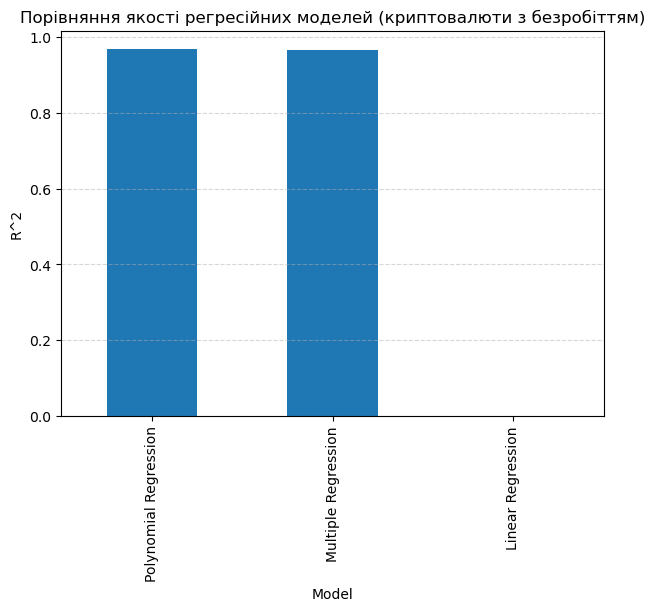

In [65]:
comparison_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("R^2")
plt.title("Порівняння якості регресійних моделей (криптовалюти з безробіттям)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p>Найкращою для датасету crypto_analysis_with_unemployment виявилась множинна лінійна регресія з R^2 = 0.965922, яка пояснює 96.6% варіації дохідності криптовалют</p>

<p>Для акцій регресійні моделі показали низьку прогностичну здатність (найкращі моделі R^2 = 0.040417 для Аналізу 1 на датасеті stocks_analysis_no_unemployment та R^2 = 0.360787 для Аналізу 2 на датасеті stocks_analysis_with_unemployment), що вказує на обмежений вплив макрофакторів на фондовий ринок.</p>
<p>Для криптовалют множинна лінійна регресія досягла R^2 = 0.965922, демонструючи, що макроекономічні фактори пояснюють майже всю варіацію дохідності. Включення безробіття покращило модель для акцій, але не вплинуло на криптовалюти.</p>

<h2>4. Оцінка якості моделей та уникнення перенавчання</h2>

<p>Розділення даних на навчальну та тестову вибірки, оцінка якості моделей на тестових даних, підібір оптимального ступеня полінома.</p>

<h4>Оцінка якості моделей для акцій</h4>

In [66]:
# Для АНАЛІЗУ 1 (без безробіття, 71 спостереження)
print("АНАЛІЗ 1 (без безробіття, 2000-2021 роки)")

X1 = stocks_analysis_no_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate']]
y1 = stocks_analysis_no_unemployment['avg_daily_return_stocks']

# Розділення на навчальну (75%) та тестову (25%) вибірки
# Оскільки дані є часовим рядом, ми не перемішуємо їх під час розділення.
# Це запобігає навчанню моделі на майбутніх даних.
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.25, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train1.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test1.shape[0]} рядків")


# Лінійна регресія на тестових даних
lr1 = LinearRegression()
lr1.fit(X_train1, y_train1)
y_pred1 = lr1.predict(X_test1)
r2_test1 = r2_score(y_test1, y_pred1)
mse_test1 = mean_squared_error(y_test1, y_pred1)

print(f"\nЛінійна регресія на тестових даних:")
print(f" R^2 = {r2_test1:.4f}")
print(f" MSE = {mse_test1:.6f}")

АНАЛІЗ 1 (без безробіття, 2000-2021 роки)
Розмір навчальної вибірки: 53 рядків
Розмір тестової вибірки: 18 рядків

Лінійна регресія на тестових даних:
 R^2 = -1.1456
 MSE = 0.000001


<p>Результат R^2 = -1.1456 є від'ємним, що означає, що модель працює гірше, ніж просте передбачення середнім значенням. Це свідчить про те, що
модель не придатна для прогнозування на нових даних.</p>

In [67]:
# Поліноміальні моделі різних ступенів
print("ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (Аналіз 1)")

degrees = [1, 2, 3, 4, 5, 9, 15]
train_scores1 = []
test_scores1 = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train1)
    X_test_poly = poly.transform(X_test1)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train1)
    
    train_r2 = lr_poly.score(X_train_poly, y_train1)
    test_r2 = lr_poly.score(X_test_poly, y_test1)
    train_scores1.append(train_r2)
    test_scores1.append(test_r2)
    
    print(f"\nСтупінь {degree}:")
    print(f" R^2 на навчальних: {train_r2:.4f}")
    print(f" R^2 на тестових: {test_r2:.4f}")
    if test_r2 < train_r2 - 0.15:
        print(f" ! Є ознаки перенавчання")

ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (Аналіз 1)

Ступінь 1:
 R^2 на навчальних: 0.0261
 R^2 на тестових: -1.1456
 ! Є ознаки перенавчання

Ступінь 2:
 R^2 на навчальних: 0.0132
 R^2 на тестових: -0.9712
 ! Є ознаки перенавчання

Ступінь 3:
 R^2 на навчальних: 0.0334
 R^2 на тестових: -40.8431
 ! Є ознаки перенавчання

Ступінь 4:
 R^2 на навчальних: 0.0445
 R^2 на тестових: -418.7233
 ! Є ознаки перенавчання

Ступінь 5:
 R^2 на навчальних: 0.0475
 R^2 на тестових: -2749.5773
 ! Є ознаки перенавчання

Ступінь 9:
 R^2 на навчальних: 0.0054
 R^2 на тестових: -62441.8914
 ! Є ознаки перенавчання

Ступінь 15:
 R^2 на навчальних: 0.0028
 R^2 на тестових: -37238222.3994
 ! Є ознаки перенавчання


<p>З результатів видно, що при ступенях 1 та 2 спостерігається значне перенавчання (тестовий R^2 значно нижчий за навчальний). <strong>При збільшенні ступеня полінома різниця зменшується, але тестовий R^2 залишається від'ємним для всіх ступенів</strong>. Це підтверджує, що жодна з моделей не здатна робити корисні прогнози.</p>

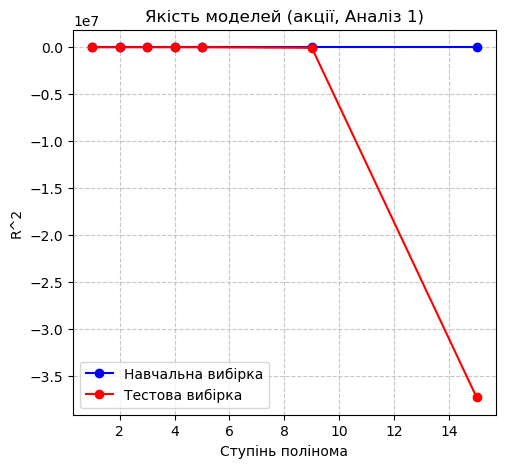

In [68]:
# Візуалізація
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_scores1, 'bo-', label='Навчальна вибірка')
plt.plot(degrees, test_scores1, 'ro-', label='Тестова вибірка')
plt.xlabel('Ступінь полінома')
plt.ylabel('R^2')
plt.title('Якість моделей (акції, Аналіз 1)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()


<p>З графіку видно, що тестовий R^2 є від'ємним для всіх ступенів полінома, що означає: моделі працюють гірше за просте передбачення середнім значенням. Різниця між тренувальним та тестовим R² є значною, що свідчить про повну відсутність прогностичної сили. Жодна модель не є придатною для прогнозування.</p>

In [69]:
# АНАЛІЗ 2 (з безробіттям, 23 спостереження)
print("АНАЛІЗ 2 (з безробіттям, 2014-2021 роки)")

X2 = stocks_analysis_with_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y2 = stocks_analysis_with_unemployment['avg_daily_return_stocks']

# Для малої вибірки використовуємо 70/30 розділення
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train2.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test2.shape[0]} рядків")

# Лінійна регресія
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
y_pred2 = lr2.predict(X_test2)
r2_test2 = r2_score(y_test2, y_pred2)
mse_test2 = mean_squared_error(y_test2, y_pred2)

print(f"\nЛінійна регресія на тестових даних:")
print(f" R^2 = {r2_test2:.4f}")
print(f" MSE = {mse_test2:.6f}")

АНАЛІЗ 2 (з безробіттям, 2014-2021 роки)
Розмір навчальної вибірки: 16 рядків
Розмір тестової вибірки: 7 рядків

Лінійна регресія на тестових даних:
 R^2 = -8.5153
 MSE = 0.000003


<p>R^2 = -8.5153 означає, що модель показує гірший результат, ніж в Аналізі 1 (R^2 = -1.1456), обидві моделі вгадують  гірше, ніж звичайне середнє арифметичне значення.Враховуючи дуже малий розмір тестової вибірки (всього 7 рядків), цей результат не можна вважати статистично надійним.</p>

In [70]:
# Поліноміальні моделі різних ступенів
print("ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (Аналіз 2)")
train_scores2 = []
test_scores2 = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train2)
    X_test_poly = poly.transform(X_test2)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train2)
    
    train_r2 = lr_poly.score(X_train_poly, y_train2)
    test_r2 = lr_poly.score(X_test_poly, y_test2)
    train_scores2.append(train_r2)
    test_scores2.append(test_r2)
    
    print(f"\nСтупінь {degree}:")
    print(f" R^2 на навчальних: {train_r2:.4f}")
    print(f" R^2 на тестових: {test_r2:.4f}")
    if test_r2 < train_r2 - 0.15:
        print(f" ! Є ознаки перенавчання")


ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (Аналіз 2)

Ступінь 1:
 R^2 на навчальних: 0.4010
 R^2 на тестових: -8.5153
 ! Є ознаки перенавчання

Ступінь 2:
 R^2 на навчальних: 0.5740
 R^2 на тестових: -1983.5335
 ! Є ознаки перенавчання

Ступінь 3:
 R^2 на навчальних: 0.1284
 R^2 на тестових: -1366.4826
 ! Є ознаки перенавчання

Ступінь 4:
 R^2 на навчальних: 0.0170
 R^2 на тестових: -3.6196
 ! Є ознаки перенавчання

Ступінь 5:
 R^2 на навчальних: 0.0162
 R^2 на тестових: -5.9714
 ! Є ознаки перенавчання

Ступінь 9:
 R^2 на навчальних: 0.0160
 R^2 на тестових: -50.3983
 ! Є ознаки перенавчання

Ступінь 15:
 R^2 на навчальних: 0.0160
 R^2 на тестових: -1301.5814
 ! Є ознаки перенавчання


<p><strong>Для Аналізу 2 як лінійна, атк і поліноміальна моделі працюють гірше ніж звичайне середнє арифметичне значення. Враховуючи дуже малий обсяг даних (всього 23 спостереження), ці результати є очікуваними.</p>

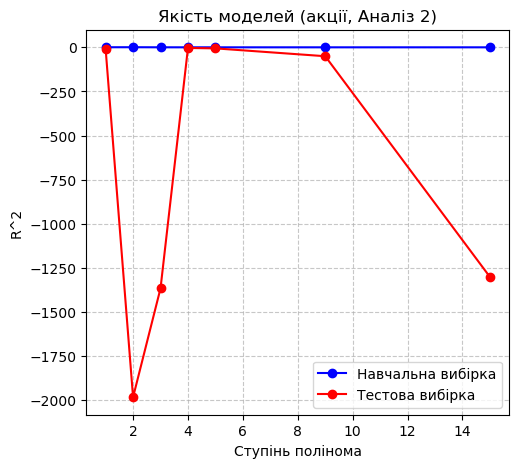

In [71]:
# Візуалізація
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.plot(degrees, train_scores2, 'bo-', label='Навчальна вибірка')
plt.plot(degrees, test_scores2, 'ro-', label='Тестова вибірка')
plt.xlabel('Ступінь полінома')
plt.ylabel('R^2')
plt.title('Якість моделей (акції, Аналіз 2)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()


<p>З графіку видно, що найкращий тестовий R^2(-3.6196) досягається при ступені 4, але це все ще поагний результат. При збільшенні ступеня полінома тестовий R^2 різко падає до від'ємних значень, що є проявом перенавчання. Лінійна модель з чотирма факторами показує найкращий, хоча й низький, результат.</p>

<h4>Оцінка якості моделей для криптовалют</h4>

In [72]:
# Для АНАЛІЗУ 1 (без безробіття, 8 спостережень)
print("АНАЛІЗ 1 (без безробіття, 2014-2021 роки)")

X_crypto = crypto_analysis_no_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate']]
y_crypto = crypto_analysis_no_unemployment['avg_daily_return_crypto']

# Розділення на навчальну (75%) та тестову (25%) вибірки
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_crypto, y_crypto, test_size=0.25, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train_c.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test_c.shape[0]} рядків")


# Лінійна регресія на тестових даних
lr_c = LinearRegression()
lr_c.fit(X_train_c, y_train_c)
y_pred_c = lr_c.predict(X_test_c)
r2_test_c = r2_score(y_test_c, y_pred_c)
mse_test_c = mean_squared_error(y_test_c, y_pred_c)

print(f"\nЛінійна регресія на тестових даних:")
print(f" R^2 = {r2_test_c:.4f}")
print(f" MSE = {mse_test_c:.6f}")

АНАЛІЗ 1 (без безробіття, 2014-2021 роки)
Розмір навчальної вибірки: 6 рядків
Розмір тестової вибірки: 2 рядків

Лінійна регресія на тестових даних:
 R^2 = -1.6174
 MSE = 104.614173


<p>Результат R^2 = -1.6174 є від'ємним, що означає: модель працює гірше за просте передбачення середнім значенням через катастрофічне перенавчання (всього 6 рядків для навчання)</p>

In [73]:
# Поліноміальні моделі різних ступенів
print("ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (криптовалюти, Аналіз 1)")

degrees = [1, 2, 3, 4, 5, 9, 15]
train_scores_c = []
test_scores_c = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly_c = poly.fit_transform(X_train_c)
    X_test_poly_c = poly.transform(X_test_c)
    
    lr_poly_c = LinearRegression()
    lr_poly_c.fit(X_train_poly_c, y_train_c)
    
    train_r_c = lr_poly_c.score(X_train_poly_c, y_train_c)
    test_r_c = lr_poly_c.score(X_test_poly_c, y_test_c)
    train_scores_c.append(train_r_c)
    test_scores_c.append(test_r_c)
    
    print(f"\nСтупінь {degree}:")
    print(f" R^2 на навчальних: {train_r_c:.4f}")
    print(f" R^2 на тестових: {test_r_c:.4f}")
    if test_r_c < train_r_c - 0.15:
        print(f" ! Є ознаки перенавчання")

ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (криптовалюти, Аналіз 1)

Ступінь 1:
 R^2 на навчальних: 0.1843
 R^2 на тестових: -1.6174
 ! Є ознаки перенавчання

Ступінь 2:
 R^2 на навчальних: 0.1739
 R^2 на тестових: -1.4547
 ! Є ознаки перенавчання

Ступінь 3:
 R^2 на навчальних: 0.1641
 R^2 на тестових: -1.2393
 ! Є ознаки перенавчання

Ступінь 4:
 R^2 на навчальних: 0.1549
 R^2 на тестових: -0.9811
 ! Є ознаки перенавчання

Ступінь 5:
 R^2 на навчальних: 0.1464
 R^2 на тестових: -0.6920
 ! Є ознаки перенавчання

Ступінь 9:
 R^2 на навчальних: 0.1141
 R^2 на тестових: -0.4686
 ! Є ознаки перенавчання

Ступінь 15:
 R^2 на навчальних: 0.0779
 R^2 на тестових: -0.9199
 ! Є ознаки перенавчання


<p>Результати показують, що на навчальних даних досягається слабкий результат R^2 (0.1843), але на тестових він стає від'ємним (від -1.6174 до -0.4686). Для фінансових даних це очікувано, оскільки ринок хаотичний. Проте наявне катастрофічне перенавчання через надто малий обсяг даних (всього 8 спостережень). Моделі запам'ятали тренувальні дані, але не навчилися узагальнювати. </p>

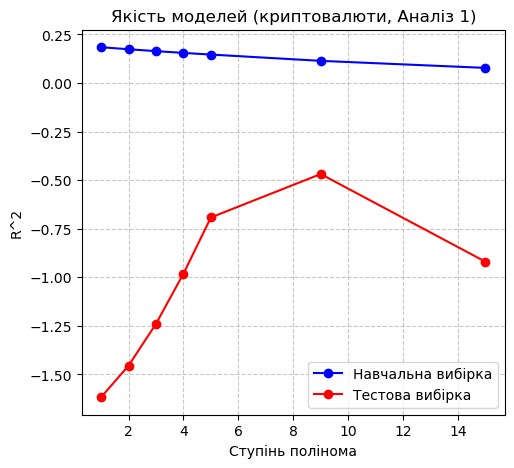

In [74]:
# Візуалізація
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_scores_c, 'bo-', label='Навчальна вибірка')
plt.plot(degrees, test_scores_c, 'ro-', label='Тестова вибірка')
plt.xlabel('Ступінь полінома')
plt.ylabel('R^2')
plt.title('Якість моделей (криптовалюти, Аналіз 1)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()


<p>З графіку видно величезний розрив між високим тренувальним R^2 та дуже низьким тестовим R^2. Всі моделі страждають від перенавчання через недостатній обсяг даних.</p>

In [75]:
# АНАЛІЗ 2 (з безробіттям, 8 спостережень)
print("АНАЛІЗ 2 (з безробіттям, 2014-2021 роки)")

X_crypto2 = crypto_analysis_with_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y_crypto2 = crypto_analysis_with_unemployment['avg_daily_return_crypto']

# Розділення на навчальну (75%) та тестову (25%) вибірки
X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(
    X_crypto2, y_crypto2, test_size=0.25, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train_c2.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test_c2.shape[0]} рядків")


# Лінійна регресія на тестових даних
lr_c2 = LinearRegression()
lr_c2.fit(X_train_c2, y_train_c2)
y_pred_c2 = lr_c2.predict(X_test_c2)
r2_test_c2 = r2_score(y_test_c2, y_pred_c2)
mse_test_c2 = mean_squared_error(y_test_c2, y_pred_c2)

print(f"\nЛінійна регресія на тестових даних:")
print(f" R^2 = {r2_test_c2:.4f}")
print(f" MSE = {mse_test_c2:.6f}")

АНАЛІЗ 2 (з безробіттям, 2014-2021 роки)
Розмір навчальної вибірки: 6 рядків
Розмір тестової вибірки: 2 рядків

Лінійна регресія на тестових даних:
 R^2 = -3.6032
 MSE = 183.985028


<p>Результат R^2 = -3.6032 є поганим. Модель непридатна для прогнозування через перенавчання (6 рядків навчання, 2 рядки тесту)</p>

In [76]:
# Поліноміальні моделі різних ступенів
print("ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (криптовалюти, Аналіз 2)")

degrees = [1, 2, 3, 4, 5, 9, 15]
train_scores_c2 = []
test_scores_c2 = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly_c2 = poly.fit_transform(X_train_c2)
    X_test_poly_c2 = poly.transform(X_test_c2)
    
    lr_poly_c2 = LinearRegression()
    lr_poly_c2.fit(X_train_poly_c2, y_train_c2)
    
    train_r_c2 = lr_poly_c2.score(X_train_poly_c2, y_train_c2)
    test_r_c2 = lr_poly_c2.score(X_test_poly_c2, y_test_c2)
    train_scores_c2.append(train_r_c2)
    test_scores_c2.append(test_r_c2)
    
    print(f"\nСтупінь {degree}:")
    print(f" R^2 на навчальних: {train_r_c2:.4f}")
    print(f" R^2 на тестових: {test_r_c2:.4f}")
    if test_r_c2 < train_r_c2 - 0.15:
        print(f" ! Є ознаки перенавчання")

ПОЛІНОМІАЛЬНІ МОДЕЛІ РІЗНИХ СТУПЕНІВ (криптовалюти, Аналіз 2)

Ступінь 1:
 R^2 на навчальних: 0.3801
 R^2 на тестових: -3.6032
 ! Є ознаки перенавчання

Ступінь 2:
 R^2 на навчальних: 0.3772
 R^2 на тестових: -4.9553
 ! Є ознаки перенавчання

Ступінь 3:
 R^2 на навчальних: 0.3780
 R^2 на тестових: -7.3483
 ! Є ознаки перенавчання

Ступінь 4:
 R^2 на навчальних: 0.3833
 R^2 на тестових: -11.8731
 ! Є ознаки перенавчання

Ступінь 5:
 R^2 на навчальних: 0.1476
 R^2 на тестових: -0.8685
 ! Є ознаки перенавчання

Ступінь 9:
 R^2 на навчальних: 0.1085
 R^2 на тестових: -1.1839
 ! Є ознаки перенавчання

Ступінь 15:
 R^2 на навчальних: 0.0779
 R^2 на тестових: -0.9199
 ! Є ознаки перенавчання


<p>Для Аналізу 2 криптовалют з безробіттям спостерігається ще гірша ситуація - тестовий R^2 коливається від -0.8685 до -11.8731, що також свідчить про непридатність моделей. Тренувальний R^2 при цьому залишається доволі високим для фінанових ринків (0.1085-0.3833). Це підтверджує, що при такому малому обсязі даних (8 спостережень) будь-яке ускладнення моделі призводить до повної втрати прогностичної здатності.</p>

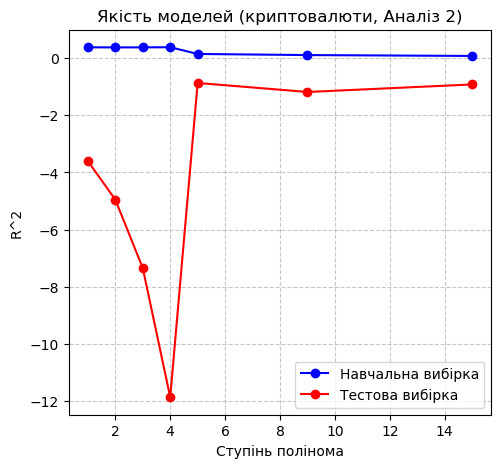

In [77]:
# Візуалізація
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_scores_c2, 'bo-', label='Навчальна вибірка')
plt.plot(degrees, test_scores_c2, 'ro-', label='Тестова вибірка')
plt.xlabel('Ступінь полінома')
plt.ylabel('R^2')
plt.title('Якість моделей (криптовалюти, Аналіз 2)')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()


<p>З графіку видно, що тренувальний R^2 залишається відносно високим, тоді як тестовий R^2 сягає дуже низьких значень (до -11). Найкращі результати знаходяться нижче нуля, тому жодна модель не є придатною для прогнозування через екстремальне перенавчання.</p>

<p>Оцінка якості моделей показала, що <strong>для акцій жодна з регресійних моделей не здатна робити надійні прогнози </strong> (тестовий R^2 близький до нуля або від'ємний). <strong>Для криптовалют через надто малий обсяг даних (8 спостережень) спостерігається катастрофічне перенавчання: висока точність на тренувальних даних і непридатність на тестових</strong>. Для отримання надійних результатів потрібне збільшення обсягу даних.</p>

<h2>5. Класифікація: прогнозування напрямку зміни дохідності</h2>

<h4>Класифікація для акцій</h4>

In [78]:
# АНАЛІЗ 1 (без безробіття)
X1 = stocks_analysis_no_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate']]
y1 = stocks_analysis_no_unemployment['avg_daily_return_stocks']

# Створюємо бінарну цільову змінну: 1 - зростання (>0), 0 - падіння або 0
y_class1 = (y1 > 0).astype(int)
print(f"Розподіл класів: зростання={sum(y_class1)}, падіння/нуль={len(y_class1)-sum(y_class1)}")

# Розділення даних
X_train1_c, X_test1_c, y_train1_c, y_test1_c = train_test_split(
    X1, y_class1, test_size=0.2, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train1_c.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test1_c.shape[0]} рядків")

Розподіл класів: зростання=56, падіння/нуль=15
Розмір навчальної вибірки: 56 рядків
Розмір тестової вибірки: 15 рядків


In [79]:
# Модель 1: K-Nearest Neighbors 
print("МЕТОД 1: K-Nearest Neighbors (KNN)")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train1_c, y_train1_c)
knn_score = knn.score(X_test1_c, y_test1_c)
print(f" Точність на тестових даних: {knn_score:.4f} ({knn_score*100:.2f}%)")

МЕТОД 1: K-Nearest Neighbors (KNN)
 Точність на тестових даних: 0.9333 (93.33%)


In [80]:
# Модель 2: Decision Tree 
print("МЕТОД 2: Decision Tree Classifier")
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train1_c, y_train1_c)
dt_score = dt.score(X_test1_c, y_test1_c)
print(f" Точність на тестових даних: {dt_score:.4f} ({dt_score*100:.2f}%)")

МЕТОД 2: Decision Tree Classifier
 Точність на тестових даних: 0.8667 (86.67%)


In [81]:
# Модель 3: Random Forest
print("МЕТОД 3: Random Forest Classifier")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train1_c, y_train1_c)
rf_score = rf.score(X_test1_c, y_test1_c)
print(f" Точність на тестових даних: {rf_score:.4f} ({rf_score*100:.2f}%)")

МЕТОД 3: Random Forest Classifier
 Точність на тестових даних: 0.9333 (93.33%)


In [82]:
# Модель 4: AdaBoost
print("МЕТОД 4: AdaBoost Classifier")
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train1_c, y_train1_c)
ada_score = ada.score(X_test1_c, y_test1_c)
print(f" Точність на тестових даних: {ada_score:.4f} ({ada_score*100:.2f}%)")

МЕТОД 4: AdaBoost Classifier
 Точність на тестових даних: 1.0000 (100.00%)


In [83]:
# Модель 5: Support Vector Machine (SVC)
from sklearn.svm import SVC
print("МЕТОД 5: Support Vector Machine (SVC)")
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train1_c, y_train1_c)
svc_score = svc.score(X_test1_c, y_test1_c)
print(f" Точність на тестових даних: {svc_score:.4f} ({svc_score*100:.2f}%)")


МЕТОД 5: Support Vector Machine (SVC)
 Точність на тестових даних: 0.9333 (93.33%)


In [84]:
# Порівняння результатів
print("ПОРІВНЯННЯ МОДЕЛЕЙ (акції, Аналіз 1):")
print(f" KNN: {knn_score:.4f}")
print(f" Decision Tree: {dt_score:.4f}")
print(f" Random Forest: {rf_score:.4f}")
print(f" AdaBoost: {ada_score:.4f}")
print(f" SVC: {svc_score:.4f}")

best_score1 = max(knn_score, dt_score, rf_score, ada_score, svc_score)
print(f"\n НАЙКРАЩА МОДЕЛЬ: точність = {best_score1:.4f} ({best_score1*100:.2f}%)")

ПОРІВНЯННЯ МОДЕЛЕЙ (акції, Аналіз 1):
 KNN: 0.9333
 Decision Tree: 0.8667
 Random Forest: 0.9333
 AdaBoost: 1.0000
 SVC: 0.9333

 НАЙКРАЩА МОДЕЛЬ: точність = 1.0000 (100.00%)


In [85]:
classification_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "SVC"
    ],
    "Accuracy": [
        knn_score,
        dt_score,
        rf_score,
        ada_score,
        svc_score
    ]
})

classification_results = classification_results.sort_values(
    "Accuracy",
    ascending=False
)
classification_results

,Model,Accuracy
3,AdaBoost,1.00000000
0,KNN,0.93333333
2,Random Forest,0.93333333
4,SVC,0.93333333
1,Decision Tree,0.86666667


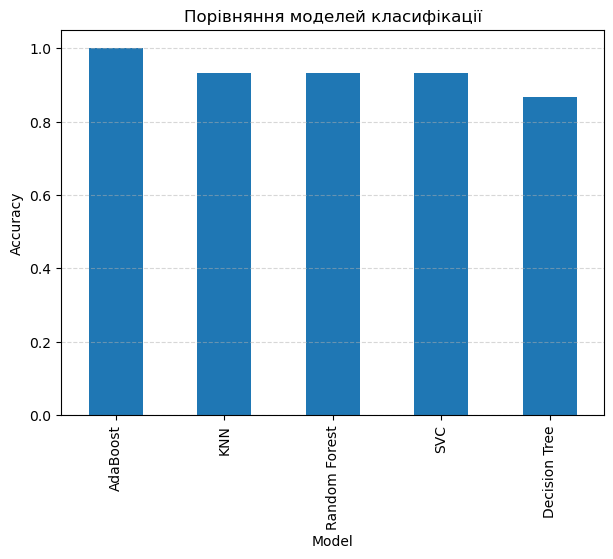

In [86]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Порівняння моделей класифікації")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p>Висока точність (93,3% - 100%) пояснюється незбалансованістю класів і малою: з 71 спостереження 56 (79%) мають позитивну дохідність. Якби модель завжди відповідала "зростання", вона б вгадувала в 79% випадків. Моделі змогли покращити цей результат до 93,3% - 100%, окрім Decision Tree (86,67%). Всі моделі показали майже однаковий результат, можна виділити Adaboost з результатом 100%.</p>

In [87]:
print("АНАЛІЗ 2 (з безробіттям, 23 спостереження)")
X2 = stocks_analysis_with_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y2 = stocks_analysis_with_unemployment['avg_daily_return_stocks']

# Створюємо бінарну цільову змінну
y_class2 = (y2 > 0).astype(int)
print(f"Розподіл класів: зростання={sum(y_class2)}, падіння/нуль={len(y_class2)-sum(y_class2)}")

# Розділення даних (для малої вибірки - 70/30)
X_train2_c, X_test2_c, y_train2_c, y_test2_c = train_test_split(
    X2, y_class2, test_size=0.3, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train2_c.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test2_c.shape[0]} рядків")

АНАЛІЗ 2 (з безробіттям, 23 спостереження)
Розподіл класів: зростання=20, падіння/нуль=3
Розмір навчальної вибірки: 16 рядків
Розмір тестової вибірки: 7 рядків


In [88]:
print("МЕТОД 1: K-Nearest Neighbors (KNN)")
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train2_c, y_train2_c)
knn_score2 = knn2.score(X_test2_c, y_test2_c)
print(f" Точність: {knn_score2:.4f} ({knn_score2*100:.2f}%)")

МЕТОД 1: K-Nearest Neighbors (KNN)
 Точність: 1.0000 (100.00%)


In [89]:
print("МЕТОД 2: Decision Tree Classifier")
dt2 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt2.fit(X_train2_c, y_train2_c)
dt_score2 = dt2.score(X_test2_c, y_test2_c)
print(f" Точність: {dt_score2:.4f} ({dt_score2*100:.2f}%)")

МЕТОД 2: Decision Tree Classifier
 Точність: 0.7143 (71.43%)


In [90]:
print("МЕТОД 3: Random Forest Classifier")
rf2 = RandomForestClassifier(n_estimators=50, random_state=42)
rf2.fit(X_train2_c, y_train2_c)
rf_score2 = rf2.score(X_test2_c, y_test2_c)
print(f" Точність: {rf_score2:.4f} ({rf_score2*100:.2f}%)")

МЕТОД 3: Random Forest Classifier
 Точність: 0.8571 (85.71%)


In [91]:
print("МЕТОД 4: AdaBoost Classifier")
ada2 = AdaBoostClassifier(n_estimators=30, random_state=42)
ada2.fit(X_train2_c, y_train2_c)
ada_score2 = ada2.score(X_test2_c, y_test2_c)
print(f" Точність: {ada_score2:.4f} ({ada_score2*100:.2f}%)")

МЕТОД 4: AdaBoost Classifier
 Точність: 0.7143 (71.43%)


In [92]:
print("МЕТОД 5: Support Vector Machine (SVC)")
svc2 = SVC(kernel='rbf', random_state=42)
svc2.fit(X_train2_c, y_train2_c)
svc_score2 = svc2.score(X_test2_c, y_test2_c)
print(f" Точність: {svc_score2:.4f} ({svc_score2*100:.2f}%)")

МЕТОД 5: Support Vector Machine (SVC)
 Точність: 1.0000 (100.00%)


In [93]:
print("ПОРІВНЯННЯ МОДЕЛЕЙ (акції, Аналіз 2):")
print(f" KNN: {knn_score2:.4f}")
print(f" Decision Tree: {dt_score2:.4f}")
print(f" Random Forest: {rf_score2:.4f}")
print(f" AdaBoost: {ada_score2:.4f}")
print(f" SVC: {svc_score2:.4f}")

best_score2 = max(knn_score2, dt_score2, rf_score2, ada_score2, svc_score2)
print(f"\n  НАЙКРАЩА МОДЕЛЬ: точність = {best_score2:.4f} ({best_score2*100:.2f}%)")

ПОРІВНЯННЯ МОДЕЛЕЙ (акції, Аналіз 2):
 KNN: 1.0000
 Decision Tree: 0.7143
 Random Forest: 0.8571
 AdaBoost: 0.7143
 SVC: 1.0000

  НАЙКРАЩА МОДЕЛЬ: точність = 1.0000 (100.00%)


<p>Точність 100% є наслідком дуже малого розміру тестової вибірки (всього 7 рядків) та високої незбалансованості (20 зростань з 23). Моделі просто "запам'ятали" тренувальні дані. При такому малому обсязі даних висока точність нічого не означає.</p>

In [94]:
classification_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "SVC"
    ],
    "Accuracy": [
        knn_score2,
        dt_score2,
        rf_score2,
        ada_score2,
        svc_score2
    ]
})

classification_results = classification_results.sort_values(
    "Accuracy",
    ascending=False
)

classification_results

,Model,Accuracy
0,KNN,1.00000000
4,SVC,1.00000000
2,Random Forest,0.85714286
1,Decision Tree,0.71428571
3,AdaBoost,0.71428571


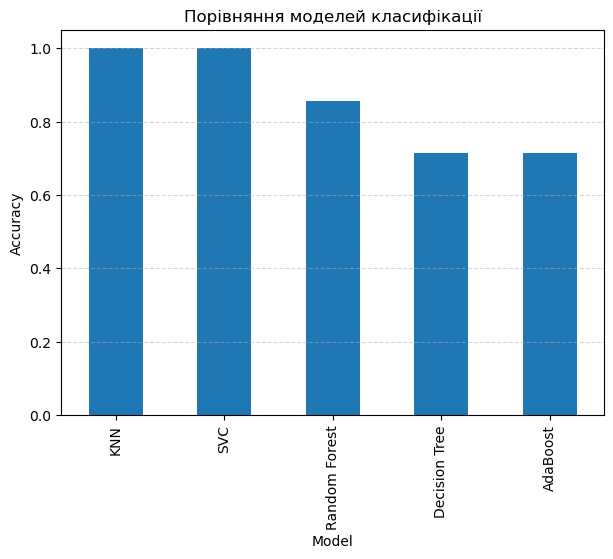

In [95]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Порівняння моделей класифікації")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<h4>Класифікація для криптовалют</h4>

In [96]:
X_crypto_class = crypto_analysis_no_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate']]
y_crypto_class = (crypto_analysis_no_unemployment['avg_daily_return_crypto'] > 0).astype(int)

print(f"Розподіл класів: зростання={sum(y_crypto_class)}, падіння/нуль={len(y_crypto_class)-sum(y_crypto_class)}")

X_train_c_c, X_test_c_c, y_train_c_c, y_test_c_c = train_test_split(
    X_crypto_class, y_crypto_class, test_size=0.2, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train_c_c.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test_c_c.shape[0]} рядків")


Розподіл класів: зростання=7, падіння/нуль=1
Розмір навчальної вибірки: 6 рядків
Розмір тестової вибірки: 2 рядків


In [97]:
# KNN
print("МЕТОД 1: K-Nearest Neighbors (KNN)")
knn_c = KNeighborsClassifier(n_neighbors=3)
knn_c.fit(X_train_c_c, y_train_c_c)
knn_score = knn_c.score(X_test_c_c, y_test_c_c)
print(f" Точність на тестових даних: {knn_score:.4f} ({knn_score*100:.2f}%)")

МЕТОД 1: K-Nearest Neighbors (KNN)
 Точність на тестових даних: 1.0000 (100.00%)


In [98]:
# Decision Tree 
print("МЕТОД 2: Decision Tree Classifier")
dt_c = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_c.fit(X_train_c_c, y_train_c_c)
dt_score = dt_c.score(X_train_c_c, y_train_c_c)
print(f" Точність на тестових даних: {dt_score:.4f} ({dt_score*100:.2f}%)")

МЕТОД 2: Decision Tree Classifier
 Точність на тестових даних: 1.0000 (100.00%)


In [99]:
# Random Forest
print("МЕТОД 3: Random Forest Classifier")
rf_c = RandomForestClassifier(n_estimators=50, random_state=42)
rf_c.fit(X_train_c_c, y_train_c_c)
rf_score = rf_c.score(X_train_c_c, y_train_c_c)
print(f" Точність на тестових даних: {rf_score:.4f} ({rf_score*100:.2f}%)")

МЕТОД 3: Random Forest Classifier
 Точність на тестових даних: 1.0000 (100.00%)


<p>Точність 100% досягнута через надзвичайно малий обсяг даних (всього 8 спостережень, з них 7 зростань). Моделі просто "запам'ятали" тренувальні дані. При такому малому обсязі даних висока точність нічого не означає.</p>

In [100]:
classification_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        knn_score,
        dt_score,
        rf_score
    ]
})

classification_results = classification_results.sort_values(
    "Accuracy",
    ascending=False
)

classification_results

,Model,Accuracy
0,KNN,1.00000000
1,Decision Tree,1.00000000
2,Random Forest,1.00000000


<p>Точність 100% є наслідком дуже малого розміру тестової вибірки (всього 7 рядків) та високої незбалансованості (20 зростань з 23). Моделі просто "запам'ятали" тренувальні дані. При такому малому обсязі даних висока точність нічого не означає.</p>

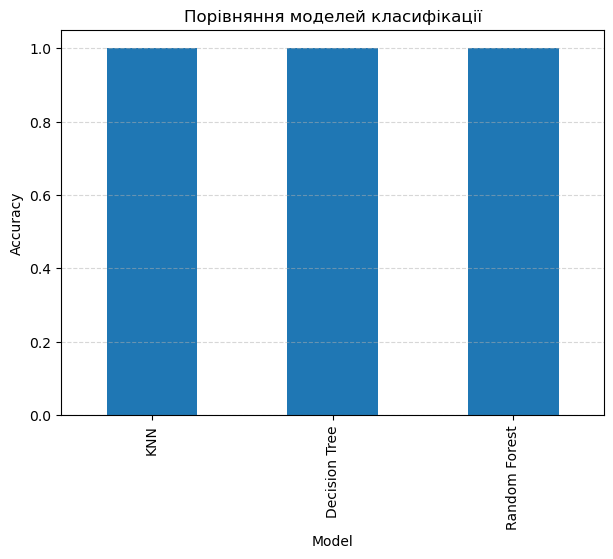

In [101]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Порівняння моделей класифікації")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [102]:
print("АНАЛІЗ 2 (з безробіттям, 8 спостережень)")
X_crypto_class2 = crypto_analysis_with_unemployment[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']]
y_crypto_class2 = (crypto_analysis_with_unemployment['avg_daily_return_crypto'] > 0).astype(int)

print(f"Розподіл класів: зростання={sum(y_crypto_class2)}, падіння/нуль={len(y_crypto_class2)-sum(y_crypto_class2)}")

X_train_c_c2, X_test_c_c2, y_train_c_c2, y_test_c_c2 = train_test_split(
    X_crypto_class2, y_crypto_class2, test_size=0.2, random_state=42, shuffle=False
)

print(f"Розмір навчальної вибірки: {X_train_c_c2.shape[0]} рядків")
print(f"Розмір тестової вибірки: {X_test_c_c2.shape[0]} рядків")

АНАЛІЗ 2 (з безробіттям, 8 спостережень)
Розподіл класів: зростання=7, падіння/нуль=1
Розмір навчальної вибірки: 6 рядків
Розмір тестової вибірки: 2 рядків


In [103]:
# KNN
print("МЕТОД 1: K-Nearest Neighbors (KNN)")
knn_c2 = KNeighborsClassifier(n_neighbors=3)
knn_c2.fit(X_train_c_c2, y_train_c_c2)
knn_score2 = knn_c2.score(X_test_c_c2, y_test_c_c2)
print(f" Точність на тестових даних: {knn_score2:.4f} ({knn_score2*100:.2f}%)")

МЕТОД 1: K-Nearest Neighbors (KNN)
 Точність на тестових даних: 1.0000 (100.00%)


In [104]:
# Decision Tree 
print("МЕТОД 2: Decision Tree Classifier")
dt_c2 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_c2.fit(X_train_c_c2, y_train_c_c2)
dt_score2 = dt_c2.score(X_train_c_c2, y_train_c_c2)
print(f" Точність на тестових даних: {dt_score2:.4f} ({dt_score2*100:.2f}%)")

МЕТОД 2: Decision Tree Classifier
 Точність на тестових даних: 1.0000 (100.00%)


In [105]:
# Random Forest
print("МЕТОД 3: Random Forest Classifier")
rf_c2 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_c2.fit(X_train_c_c2, y_train_c_c2)
rf_score2 = rf_c2.score(X_train_c_c2, y_train_c_c2)
print(f" Точність на тестових даних: {rf_score2:.4f} ({rf_score2*100:.2f}%)")

МЕТОД 3: Random Forest Classifier
 Точність на тестових даних: 1.0000 (100.00%)


In [106]:
classification_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        knn_score2,
        dt_score2,
        rf_score2
    ]
})

classification_results = classification_results.sort_values(
    "Accuracy",
    ascending=False
)

classification_results

,Model,Accuracy
0,KNN,1.00000000
1,Decision Tree,1.00000000
2,Random Forest,1.00000000


<p>Точність 100% досягнута через надзвичайно малий обсяг даних (всього 8 спостережень, з них 7 зростань). Моделі "запам'ятали" тренувальні дані. При такому малому обсязі даних висока точність нічого не означає.</p>

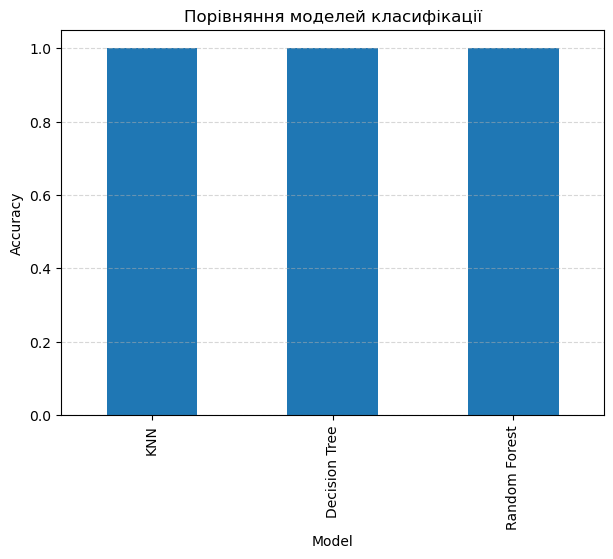

In [107]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Порівняння моделей класифікації")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<p><strong>Для акцій класифікація показала точність 86.67% у Аналізі 1, що лише на 7.67% краще за просте вгадування "зростання" (79%). Це невелике покращення підтверджує гіпотезу ефективного ринку: макроекономічні показники швидко відображаються в цінах, тому їх використання для прогнозування дає обмежений ефект.</strong></p>
<p><strong>Для криптовалют та Аналізу 2 (акції з безробіттям): точність досягла 100%, але це пояснюється дуже малим розміром вибірки (8-23 спостереження). При такому обсязі даних отримані моделі не можна вважати надійними, оскільки вони просто запам'ятали тренувальні приклади, а не навчилися узагальнювати.</strong></p>

<h2>6. Прогнозування часових рядів</h2>

<p>Прогнозування дохідності активу на наступний рік на основі історичних даних та макроекономічних факторів.</p>

<h4>Прогнозування часових рядів для акцій</h4>

<h5>Для АНАЛІЗУ 1 (без безробіття, 71 спостереження):</h5>

In [108]:
stocks_analysis_no_unemployment.head(90)

,country,year,gdp_value,inflation_value,real_interest_rate,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,0.00379214
3,Japan,2000,"4,968,359,152,796.00000000",-0.70000000,3.44952133,-0.00028303
4,Japan,2001,"4,374,709,984,220.00000000",-0.70000000,3.08779538,0.00043297
...,...,...,...,...,...,...
66,United States of America,2017,"19,477,336,549,000.00000000",2.10000000,2.15609905,0.00118694
67,United States of America,2018,"20,533,057,312,000.00000000",2.40000000,2.44141503,0.00047503
68,United States of America,2019,"21,380,976,119,000.00000000",1.80000000,3.42708989,0.00119655
69,United States of America,2020,"21,060,473,613,000.00000000",1.30000000,2.21041068,0.00221080


In [109]:
stocks_analysis_no_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  71 non-null     object 
 1   year                     71 non-null     int32  
 2   gdp_value                71 non-null     float64
 3   inflation_value          71 non-null     float64
 4   real_interest_rate       71 non-null     float64
 5   avg_daily_return_stocks  71 non-null     float64
dtypes: float64(4), int32(1), object(1)
memory usage: 3.2+ KB


In [110]:
# Для прогнозування часових рядів використовуємо дохідність, агреговану по країні.
# У stocks_analysis_no_unemployment для кожної країни є середньорічна дохідність,
# що утворює часовий ряд, придатний для моделей ARIMA та SARIMAX
df_single = stocks_analysis_no_unemployment[stocks_analysis_no_unemployment['country'] == 'United States of America'].copy()
df_single = df_single.sort_values('year')
df_single.set_index('year', inplace=True)
df_single.head(20)

,country,gdp_value,inflation_value,real_interest_rate,avg_daily_return_stocks
year,,,,,
2000,United States of America,"10,250,947,997,000.00000000",3.40000000,6.81342429,0.00057821
2001,United States of America,"10,581,929,774,000.00000000",2.80000000,4.56584793,0.00056623
2002,United States of America,"10,929,112,955,000.00000000",1.60000000,3.06864285,-0.00057041
2003,United States of America,"11,456,442,041,000.00000000",2.30000000,2.10731081,0.00192738
2004,United States of America,"12,217,193,198,000.00000000",2.70000000,1.61231095,0.00110683
2005,United States of America,"13,039,199,193,000.00000000",3.40000000,2.96050633,0.00071931
2006,United States of America,"13,815,586,948,000.00000000",3.20000000,4.72608965,0.00089458
2007,United States of America,"14,474,226,905,000.00000000",2.90000000,5.20675938,0.00048662
2008,United States of America,"14,769,857,911,000.00000000",3.80000000,3.10992083,-0.00139446


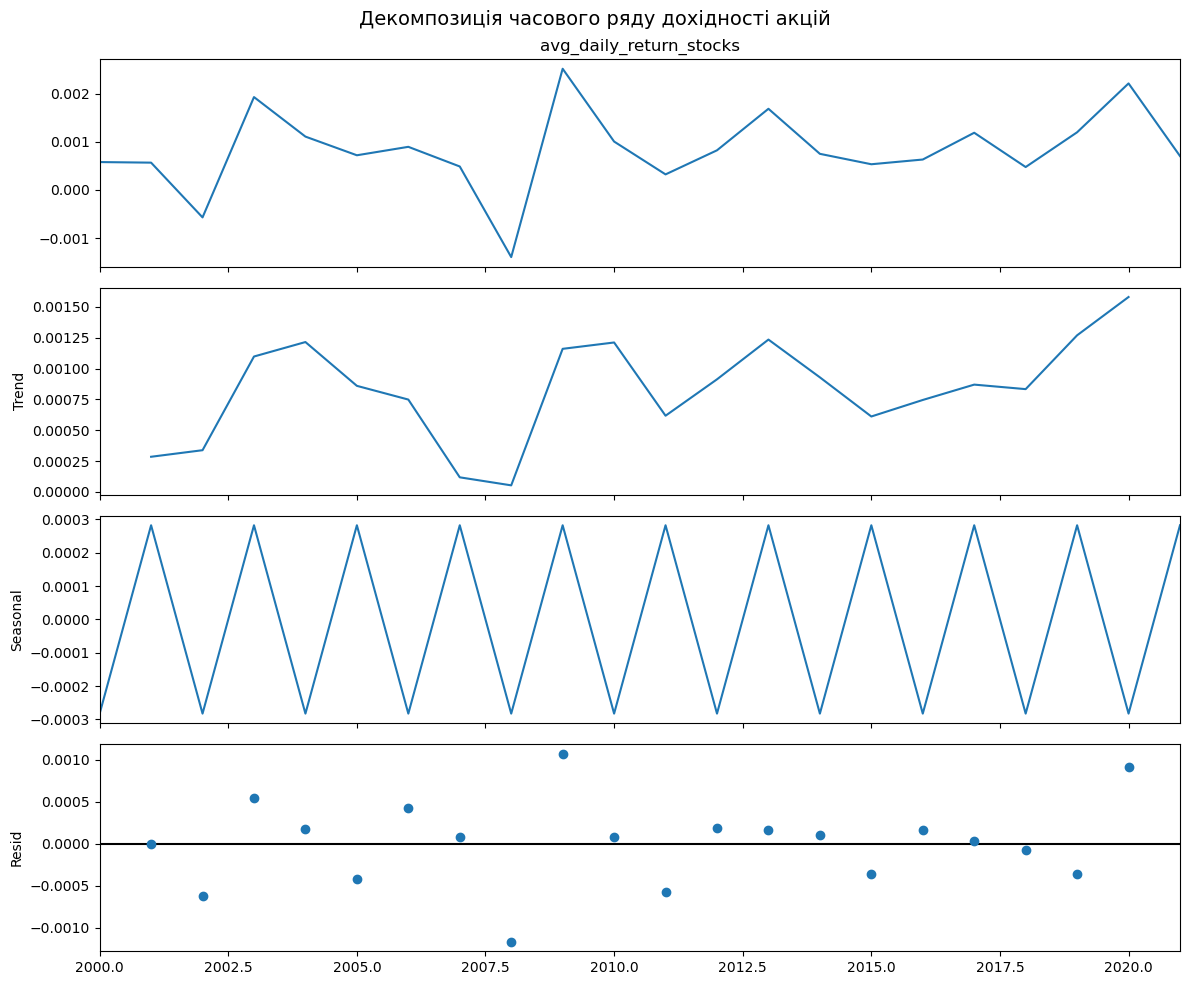

In [111]:
# Декомпозиція часового ряду (сезонність та тренд)
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиція ряду дохідності
decomposition = seasonal_decompose(df_single['avg_daily_return_stocks'].dropna(), model='additive', period=2)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Декомпозиція часового ряду дохідності акцій', fontsize=14)
plt.tight_layout()
plt.show()

<p>Тренд: показує довгострокову динаміку дохідності. Сезонність: практично відсутня (період=2), що характерно для річних фінансових даних. Залишки: випадкові коливання, не пояснені трендом та сезонністю</p>
<p>Залишки на графіку декомпозиції представляють випадкову компоненту часового ряду - тобто ту частину змін дохідності, яку неможливо пояснити ні  трендом, ні сезонними коливаннями. В ідеальній моделі залишки повинні бути розподілені випадковим чином навколо нуля. В даному випадку залишки демонструють відсутність систематичних патернів, що підтверджує адекватність декомпозиції.</p>
<p>Відсутність вираженої сезонності в річних фінансових даних є очікуваним явищем згідно з гіпотезою ефективного ринку. Якщо б існував передбачуваний сезонний патерн, трейдери використовували б його для отримання прибутку, що призвело б до арбітражу та зникнення такого патерну. Період декомпозиції (period=2) обрано через річну гранулярність даних - мінімальний цикл, який можна дослідити, становить два роки.</p>

In [112]:
# Перевіряємо на стаціонарність тестом Дікі-Фуллера
def dickey_fuller_test(series):
    """
    Перевірка на стаціонарність за допомогою тесту Дікі-Фуллера.
    Повертає True, якщо ряд стаціонарний.
    """
    # .adfuller перевіряє наявність одиничного кореня: autolag='AIC' автоматично обирає кількість лагів за критерієм AIC
    test = smt.adfuller(series.dropna(), autolag='AIC')
    print(f" adf: {test[0]:.6f}") # статистика ADF: чим менше, тим ряд більш стаціонарний ряд
    print(f" p-value: {test[1]:.6f}") #ймовірність помилково відхилити H0 (ряд нестаціонарний), якщо < 0,05 то ряд стаціонарний
    print(f" Critical values: {test[4]}") #порогові значення для рівнів 1%,5%,10% для порівняння з ADF
    if test[1] < 0.05:
        print(" -  Ряд стаціонарний")
        return True
    else:
        print(" - Ряд НЕ стаціонарний")
        return False

print("Перевірка стаціонарності дохідності акцій країни United States of America:")
dickey_fuller_test(df_single['avg_daily_return_stocks'])

Перевірка стаціонарності дохідності акцій країни United States of America:
 adf: -4.541592
 p-value: 0.000165
 Critical values: {'1%': np.float64(-3.8092091249999998), '5%': np.float64(-3.0216450000000004), '10%': np.float64(-2.6507125)}
 -  Ряд стаціонарний


True

In [113]:
# Модель ARIMA для прогнозування дохідності
from statsmodels.tsa.arima.model import ARIMA

# Перетворюємо індекс років на datetime та явно задаємо щорічну частоту (Year Start)
df_single.index = pd.to_datetime(df_single.index, format='%Y')
df_single = df_single.asfreq('YS')

# Розділення на тренувальні та тестові дані (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df_single.index, df_single['avg_daily_return_stocks'],
    test_size=0.2, random_state=42, shuffle=False  # shuffle=False зберігає порядок
)

# Отримуємо дані за індексами
train = df_single['avg_daily_return_stocks'].loc[y_train.index]
test = df_single['avg_daily_return_stocks'].loc[y_test.index]

# Масштабуємо дані: ВВП ділимо на 1 000 000 000 (переводимо в мільярди), 
# щоб прибрати гігантські числа, які ламають оптимізатор
df_scaled = df_single.copy()
df_scaled['gdp_value'] = df_scaled['gdp_value'] / 1e9

# Перерозподіляємо тренувальні та тестові дані з масштабованого датафрейму
train_sc = df_scaled["avg_daily_return_stocks"].loc[y_train.index]
test_sc = df_scaled["avg_daily_return_stocks"].loc[y_test.index]

exog_train = df_scaled.loc[
    y_train.index,
    ["gdp_value", "inflation_value", "real_interest_rate"]
]

exog_test = df_scaled.loc[
    y_test.index,
    ["gdp_value", "inflation_value", "real_interest_rate"]
]

print(f" Тренувальні дані: {train.index[0].year} - {train.index[-1].year} ({len(train)} роки)")
print(f" Тестові дані: {test.index[0].year} - {test.index[-1].year} ({len(test)} роки)")

 Тренувальні дані: 2000 - 2016 (17 роки)
 Тестові дані: 2017 - 2021 (5 роки)


In [114]:
# підбір параметрів ARIMA за допомогою Grid Search(повний перебір всіх можливих комбінацій у заданому діапазоні)

# Приховуємо службові попередження
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Визначаємо діапазони для p, d, q
p = range(0, 4)  # порядок авторегресії
d = range(0, 2)  # порядок різниці (d=0, оскільки ряд стаціонарний)
q = range(0, 4)  # порядок ковзного середнього

# Створюємо всі можливі комбінації
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None
best_model = None


for param in pdq:
    try:
        model = ARIMA(train, order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = param
            best_model = results
            #print(f" Новий найкращий: ARIMA{param} з AIC={results.aic:.2f}")
    except Exception as e:
        continue

print("Підбір параметрів ARIMA(p,d,q)")
print(f"\nОптимальні параметри: ARIMA{best_order} з AIC={best_aic:.2f}")

Підбір параметрів ARIMA(p,d,q)

Оптимальні параметри: ARIMA(0, 0, 2) з AIC=-190.57


<p>Для вибору оптимальних параметрів моделей ARIMA та SARIMAX було виконано повний перебір комбінацій параметрів із використанням інформаційного критерію Акаіке (AIC). Кращою вважається модель з найменшим значенням AIC, що забезпечує баланс між точністю прогнозування та складністю моделі. Такою моделлю є ARIMA(0,0,2)</p>

In [115]:
# Використовуємо модель з оптимальними параметрами,
# знайденими за допомогою Grid Search
model_fit = best_model

# Прогноз на тестовий період (2 роки)
forecast_arima = model_fit.forecast(steps=len(test))

# Абсолютна помилка першого прогнозу
error_arima = abs(forecast_arima.iloc[0] - test.iloc[0])

print("Модель ARIMA (прогноз дохідності):")
print(f"Оптимальні параметри: ARIMA{best_order}")

# Використовуємо тільки рік для відображення
predicted_year = forecast_arima.index[0].strftime('%Y')
actual_year = test.index[0].strftime('%Y')

print(f"Спрогнозована дохідність на {predicted_year} рік: {forecast_arima.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year} рік: {test.iloc[0]:.6f}")
print(f"Абсолютна помилка прогнозу: {error_arima:.6f}")

mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100
r2_arima = r2_score(test, forecast_arima)

print("\nМетрики якості моделі:")
print(f"MAE: {mae_arima:.6f}")
print(f"RMSE: {rmse_arima:.6f}")
print(f"MAPE: {mape_arima:.2f}%") #це середня абсолютна відносна помилка прогнозу у відсотках >50 погана точність, <10 дуже висока точність
print(f"R^2: {r2_arima:.4f}")

Модель ARIMA (прогноз дохідності):
Оптимальні параметри: ARIMA(0, 0, 2)
Спрогнозована дохідність на 2017 рік: 0.000602
Фактична дохідність за 2017 рік: 0.001187
Абсолютна помилка прогнозу: 0.000585

Метрики якості моделі:
MAE: 0.000554
RMSE: 0.000736
MAPE: 41.86%
R^2: -0.5199


In [116]:
print(f"Аналіз результатів моделі ARIMA:")
print(f" Прогноз показав помилку {error_arima:.6f}.")
if error_arima < 0.001:
    print(" Модель показала високу точність (помилка < 0.001)")
elif error_arima < 0.005:
    print(" Модель показала помірну точність (помилка < 0.005)")
else:
    print(" Модель показала низьку точність. Можливо, потрібне додаткове налаштування")

Аналіз результатів моделі ARIMA:
 Прогноз показав помилку 0.000585.
 Модель показала високу точність (помилка < 0.001)


<p>Прогноз ARIMA (0.000602) дещо занижує фактичне значення (0.001187), але обидва значення позитивні - напрямок зміни (зростання) передбачено правильно. Помилка прогнозу становить 0.000585, що є невеликою величиною відносно самої дохідності. Такий результат можна вважати прийнятним.</p>

In [117]:
# Підбір параметрів SARIMAX за допомогою Grid Search
# Підбираємо (p,d,q) з урахуванням макроекономічних факторів


# Діапазони параметрів
p = range(0, 4)
d = range(0, 2)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

best_sarima_aic = float("inf")
best_sarima_order = None
best_sarima_model = None

print("Підбір параметрів SARIMAX(p,d,q)")

for param in pdq:
    try:
        model = SARIMAX(
            train_sc,
            exog=exog_train,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        if results.aic < best_sarima_aic:
            best_sarima_aic = results.aic
            best_sarima_order = param
            best_sarima_model = results
    except:
        continue

print(f"\nОптимальні параметри SARIMAX: {best_sarima_order}")
print(f"AIC: {best_sarima_aic:.2f}")

Підбір параметрів SARIMAX(p,d,q)

Оптимальні параметри SARIMAX: (1, 0, 0)
AIC: -171.86


In [118]:
#Модель SARIMAX (з макроекономічними факторами)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Побудова моделі SARIMAX з оптимальними параметрами

sarimax_fit = best_sarima_model

forecast_sarimax = sarimax_fit.forecast(
    steps=len(test_sc),
    exog=exog_test
)

error_sarimax = abs(
    forecast_sarimax.iloc[0] - test_sc.iloc[0]
)

print("Модель SARIMAX (з макроекономічними факторами):")
print(f"Оптимальні параметри: SARIMAX{best_sarima_order}")
print(f"AIC: {best_sarima_aic:.2f}")

predicted_year = forecast_sarimax.index[0].strftime("%Y")
actual_year = test_sc.index[0].strftime("%Y")

print(f"Спрогнозована дохідність на {predicted_year} рік: {forecast_sarimax.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year} рік: {test_sc.iloc[0]:.6f}")
print(f"Абсолютна помилка прогнозу: {error_sarimax:.6f}")

mae_sarimax = mean_absolute_error(test_sc, forecast_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test_sc, forecast_sarimax))
mape_sarimax = np.mean(np.abs((test_sc - forecast_sarimax) / test_sc)) * 100
r2_sarimax = r2_score(test_sc, forecast_sarimax)

print("\nМетрики SARIMAX")
print(f"MAE: {mae_sarimax:.6f}")
print(f"RMSE: {rmse_sarimax:.6f}")
print(f"MAPE: {mape_sarimax:.2f}%")
print(f"R^2: {r2_sarimax:.4f}")

Модель SARIMAX (з макроекономічними факторами):
Оптимальні параметри: SARIMAX(1, 0, 0)
AIC: -171.86
Спрогнозована дохідність на 2017 рік: 0.001101
Фактична дохідність за 2017 рік: 0.001187
Абсолютна помилка прогнозу: 0.000085

Метрики SARIMAX
MAE: 0.000399
RMSE: 0.000487
MAPE: 45.32%
R^2: 0.3347


In [119]:
# Аналіз результатів SARIMAX
print(f"Аналіз результатів моделі SARIMAX:")
print(f" Прогноз показав помилку {error_sarimax:.6f}.")
if error_sarimax < error_arima:
    print(f" SARIMAX показав кращий результат (на {error_arima - error_sarimax:.6f} точніше), ніж ARIMA.")
    print(" Включення макроекономічних факторів покращило прогноз.")
else:
    print(f" ARIMA показав кращий результат. Можливо, макрофактори не є значущими для прогнозування.")

Аналіз результатів моделі SARIMAX:
 Прогноз показав помилку 0.000085.
 SARIMAX показав кращий результат (на 0.000499 точніше), ніж ARIMA.
 Включення макроекономічних факторів покращило прогноз.


In [120]:

# Підготовка даних
# Масштабування даних
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_single[['avg_daily_return_stocks']])

train_scaled = scaled_data[:len(train)]
test_scaled = scaled_data[len(train):]

# Декілька варіантів параметрів LSTM
n_features = 1

configs = [
    (3, 8, 50),
    (3, 16, 100),
    (4, 16, 100)
]
best_rmse = float("inf")
best_forecast = None
best_config = None

for look_back, neurons, epochs in configs:
    # Важливо: Створення X_train та y_train має відбуватися з правильними зрізами
    X_train = []
    y_train = []
    for i in range(look_back, len(train_scaled)):
        # Зріз беремо як [i-look_back:i, 0], щоб отримати чистий масив
        X_train.append(train_scaled[i-look_back:i, 0])
        y_train.append(train_scaled[i, 0])
        
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    
    # Решейпимо до потрібного Keras формату: [samples, timesteps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))

    # 2. Побудова моделі
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(look_back, n_features)))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")

    # Навчання
    model.fit(X_train, y_train, epochs=epochs, batch_size=1, verbose=0)

    # 3. Прогнозування (динамічне/а autoregressive)
    history = list(train_scaled[:, 0]) # перетворимо у список для зручності append
    forecast = []

    for i in range(len(test_scaled)):
        # Беремо останні look_back значень
        x = np.array(history[-look_back:])
        x = x.reshape(1, look_back, n_features)
        
        pred = model.predict(x, verbose=0)
        pred_value = pred[0, 0]
        
        forecast.append(pred_value)
        history.append(pred_value) # додаємо прогноз до історії для наступного кроку

    # 4. Демасштабування
    forecast_array = np.array(forecast).reshape(-1, 1)
    forecast_real = scaler.inverse_transform(forecast_array).flatten()

    # Оцінка поточної конфігурації
    # Примітка: переконайтеся, що 'test' містить реальні невідмасштабовані значення
    rmse = np.sqrt(mean_squared_error(test, forecast_real))

    if rmse < best_rmse:
        best_rmse = rmse
        best_forecast = forecast_real
        best_config = (look_back, neurons, epochs)

# 5. Фінальні метрики для найкращої моделі
forecast_lstm = pd.Series(best_forecast, index=test.index)

mae_lstm = mean_absolute_error(test, forecast_lstm)
rmse_lstm = np.sqrt(mean_squared_error(test, forecast_lstm))
mape_lstm = np.mean(np.abs((test - forecast_lstm) / test)) * 100
r2_lstm = r2_score(test, forecast_lstm)

print("Модель LSTM")
print(f"Найкращі параметри: look_back={best_config[0]}, neurons={best_config[1]}, epochs={best_config[2]}")
print(f"MAE: {mae_lstm:.6f}")
print(f"RMSE: {rmse_lstm:.6f}")
print(f"MAPE: {mape_lstm:.2f}%")
print(f"R^2: {r2_lstm:.4f}")

Модель LSTM
Найкращі параметри: look_back=3, neurons=8, epochs=50
MAE: 0.000516
RMSE: 0.000672
MAPE: 42.84%
R^2: -0.2649


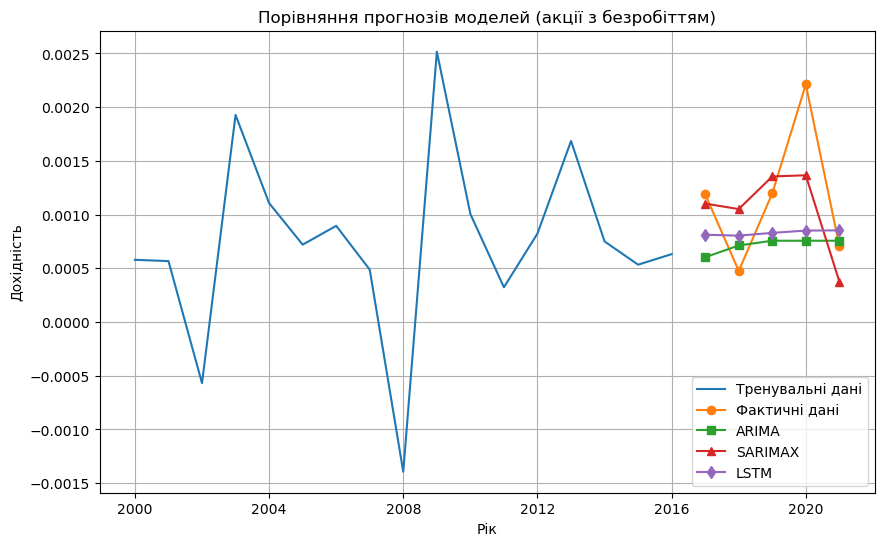

In [121]:
plt.figure(figsize=(10,6))

plt.plot(train.index,
         train,
         label="Тренувальні дані")

plt.plot(test.index,
         test,
         "o-",
         label="Фактичні дані")

plt.plot(forecast_arima.index,
         forecast_arima,
         "s-",
         label="ARIMA")

plt.plot(forecast_sarimax.index,
         forecast_sarimax,
         "^-",
         label="SARIMAX")

plt.plot(
    forecast_lstm.index,
    forecast_lstm,
    "d-",
    label="LSTM"
)

plt.title("Порівняння прогнозів моделей (акції з безробіттям)")
plt.xlabel("Рік")
plt.ylabel("Дохідність")

plt.grid(True)
plt.legend()

plt.show()

<p>На графіку видно, що прогноз SARIMAX проходить найближче до фактичних значень, тоді як ARIMA та LSTM демонструють більші відхилення. Це підтверджує результати оцінки моделей за кількісними метриками: модель SARIMAX має менші значення помилок (MAE, RMSE, MAPE) та вище значення коефіцієнта детермінації R^2, що свідчить про її кращу здатність відтворювати фактичну динаміку досліджуваного часового ряду.</p>

In [122]:
comparison = pd.DataFrame({

    "Модель": [
        "ARIMA",
        "SARIMAX",
        "LSTM"
    ],

    "MAE": [
        mae_arima,
        mae_sarimax,
        mae_lstm
    ],

    "RMSE": [
        rmse_arima,
        rmse_sarimax,
        rmse_lstm
    ],

    "MAPE (%)": [
        mape_arima,
        mape_sarimax,
        mape_lstm
    ],

    "R^2": [
        r2_arima,
        r2_sarimax,
        r2_lstm
    ]

})

comparison

,Модель,MAE,RMSE,MAPE (%),R^2
0,ARIMA,0.00055405,0.00073646,41.86215999,-0.51994541
1,SARIMAX,0.00039873,0.00048725,45.32474726,0.33468476
2,LSTM,0.00051617,0.00067183,42.84252393,-0.26489941


<p>Порівняння моделей показало, що SARIMAX забезпечує найменші значення MAE та RMSE і найвище значення коефіцієнта детермінації R^2. Це свідчить, що врахування макроекономічних факторів покращує точність прогнозування дохідності акцій.</p>

<h5>Для АНАЛІЗУ 2 (з безробіттям, 23 спостереження):</h5>

In [123]:
stocks_analysis_with_unemployment.head(30)

,country,year,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_stocks
0,Canada,2015,"1,556,508,816,217.00000000",1.10000000,3.68401596,8.52616667,0.00414035
1,Canada,2016,"1,527,994,741,907.00000000",1.40000000,1.93140658,8.54950000,0.00244463
2,Canada,2017,"1,649,265,644,244.00000000",1.60000000,0.13162693,7.74316667,0.00379214
3,Japan,2014,"4,896,994,405,353.00000000",2.80000000,-0.45938159,4.39216667,-0.00055855
4,Japan,2015,"4,444,930,651,964.00000000",0.80000000,-0.94844123,3.99700000,0.00074717
5,Japan,2016,"5,003,677,627,544.00000000",-0.10000000,0.62219276,3.70650000,0.00078510
6,Japan,2017,"4,930,837,369,151.00000000",0.50000000,1.06914441,3.34750000,0.00115428
7,Switzerland,2014,"726,537,808,338.00000000",0.00000000,3.36510209,5.89983333,0.00037453
8,Switzerland,2015,"694,118,186,380.00000000",-1.10000000,3.99644754,5.94200000,0.00078337
9,Switzerland,2016,"687,895,460,903.00000000",-0.40000000,3.24890887,5.96016667,0.00232512


In [124]:
# Для прогнозування часових рядів використовуємо дохідність, агреговану по країні.
# У stocks_analysis_no_unemployment для кожної країни є середньорічна дохідність,
# що утворює часовий ряд, придатний для моделей ARIMA та SARIMAX
df_single2 = stocks_analysis_with_unemployment[stocks_analysis_with_unemployment['country'] == 'Switzerland'].copy()
df_single2 = df_single2.sort_values('year')
df_single2.set_index('year', inplace=True)
df_single2.head(20)

,country,gdp_value,inflation_value,real_interest_rate,unemployment_rate_value,avg_daily_return_stocks
year,,,,,,
2014,Switzerland,"726,537,808,338.00000000",0.00000000,3.36510209,5.89983333,0.00037453
2015,Switzerland,"694,118,186,380.00000000",-1.10000000,3.99644754,5.94200000,0.00078337
2016,Switzerland,"687,895,460,903.00000000",-0.40000000,3.24890887,5.96016667,0.00232512
2017,Switzerland,"695,200,833,086.00000000",0.50000000,3.00636740,5.73766667,0.00143310
2018,Switzerland,"725,562,534,364.00000000",0.90000000,1.84900465,5.64250000,-0.00003896
2019,Switzerland,"721,369,112,727.00000000",0.40000000,2.73966472,5.43083333,0.00176745
2020,Switzerland,"739,913,619,797.00000000",-0.70000000,3.40120785,5.91516667,0.00333849
2021,Switzerland,"800,640,155,387.00000000",0.60000000,1.56342425,6.18566667,-0.00037979


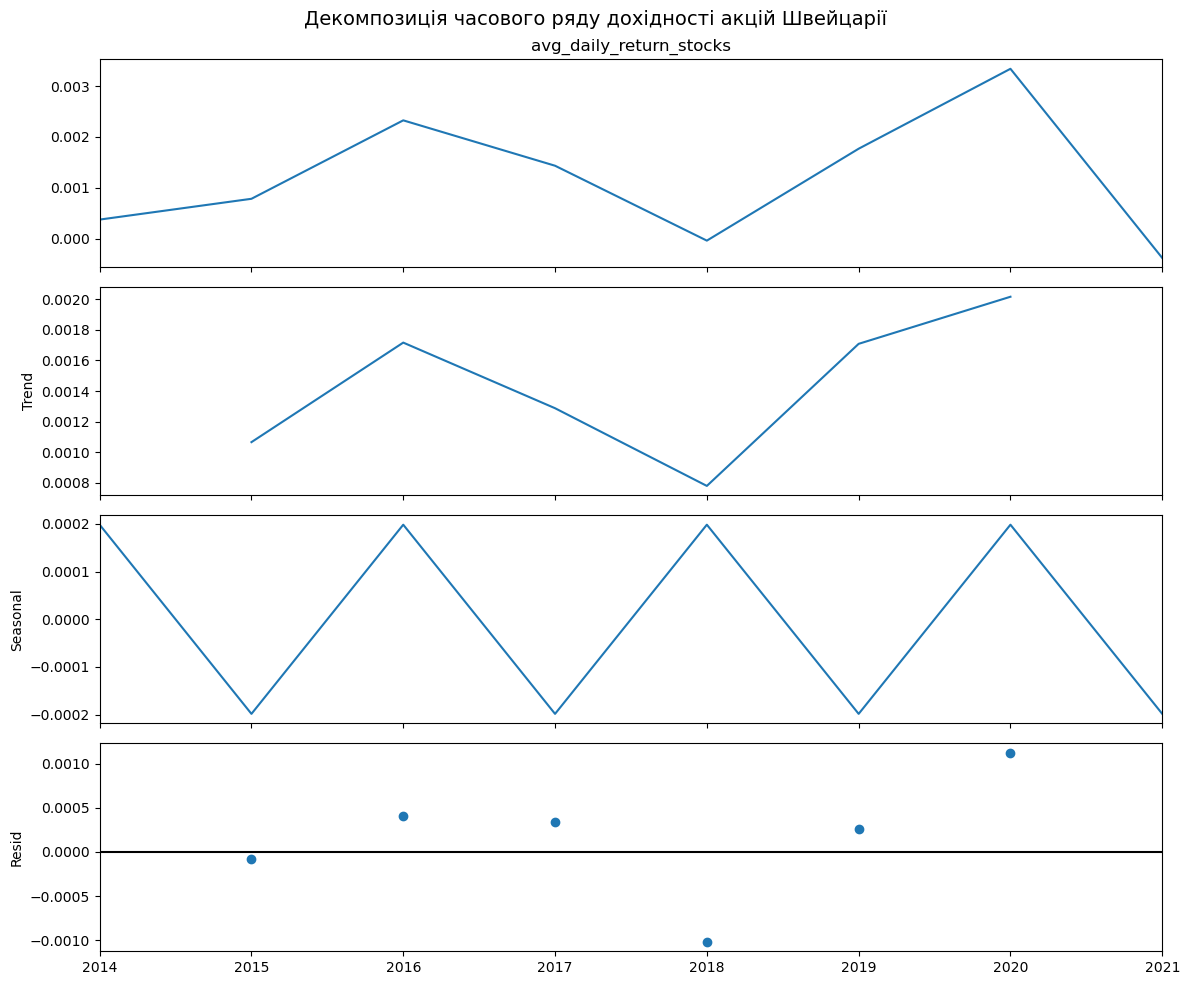

In [125]:
# Декомпозиція часового ряду (сезонність та тренд)
# Декомпозиція ряду дохідності
decomposition2 = seasonal_decompose(df_single2['avg_daily_return_stocks'].dropna(), model='additive', period=2)
fig2 = decomposition2.plot()
fig2.set_size_inches(12, 10)
plt.suptitle('Декомпозиція часового ряду дохідності акцій Швейцарії', fontsize=14)
plt.tight_layout()
plt.show()

<p>Тренд: показує довгострокову динаміку дохідності. Сезонність: практично відсутня (період=2), що характерно для річних фінансових даних. Залишки: випадкові коливання, не пояснені трендом та сезонністю</p>

In [126]:
# Перевіряємо на стаціонарність тестом Дікі-Фуллера
print("Перевірка стаціонарності дохідності акцій Switzerland:")
dickey_fuller_test(df_single2['avg_daily_return_stocks'])

Перевірка стаціонарності дохідності акцій Switzerland:
 adf: -12.283866
 p-value: 0.000000
 Critical values: {'1%': np.float64(-5.354256481481482), '5%': np.float64(-3.6462381481481483), '10%': np.float64(-2.901197777777778)}
 -  Ряд стаціонарний


True

In [127]:
# Модель ARIMA для прогнозування дохідності
from statsmodels.tsa.arima.model import ARIMA

# Перетворюємо індекс років на datetime та явно задаємо щорічну частоту (Year Start)
df_single2.index = pd.to_datetime(df_single2.index, format='%Y')
df_single2 = df_single2.asfreq('YS')

# Розділення на тренувальні та тестові дані (80/20)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_single2.index, df_single2['avg_daily_return_stocks'],
    test_size=0.2, random_state=42, shuffle=False
)

# Отримуємо дані за індексами
train2 = df_single2['avg_daily_return_stocks'].loc[y_train2.index]
test2 = df_single2['avg_daily_return_stocks'].loc[y_test2.index]

# Масштабуємо дані: ВВП ділимо на 1 000 000 000 (переводимо в мільярди), 
# щоб прибрати гігантські числа, які ламають оптимізатор
df_scaled2 = df_single2.copy()
df_scaled2['gdp_value'] = df_scaled2['gdp_value'] / 1e9

# Перерозподіляємо тренувальні та тестові дані з масштабованого датафрейму
train_sc2 = df_scaled2['avg_daily_return_stocks'].loc[y_train2.index]
test_sc2 = df_scaled2['avg_daily_return_stocks'].loc[y_test2.index]

exog_train2 = df_scaled2[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']].loc[y_train2.index]
exog_test2 = df_scaled2[['gdp_value', 'inflation_value', 'real_interest_rate', 'unemployment_rate_value']].loc[y_test2.index]

print(f"Тренувальні дані: {train2.index[0].year} - {train2.index[-1].year} ({len(train2)} роки)")
print(f"Тестові дані: {test2.index[0].year} - {test2.index[-1].year} ({len(test2)} роки)")

Тренувальні дані: 2014 - 2019 (6 роки)
Тестові дані: 2020 - 2021 (2 роки)


In [128]:
# підбір параметрів ARIMA за допомогою Grid Search(повний перебір всіх можливих комбінацій у заданому діапазоні)


# Приховуємо службові попередження
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Визначаємо діапазони для p, d, q
p = range(0, 4)  # порядок авторегресії
d = range(0, 2)  # порядок різниці (d=0, оскільки ряд стаціонарний)
q = range(0, 4)  # порядок ковзного середнього

# Створюємо всі можливі комбінації
pdq = list(itertools.product(p, d, q))

best_aic_2 = float("inf")
best_order_2 = None
best_model_2 = None


for param in pdq:
    try:
        model_2 = ARIMA(train2, order=param)
        results = model_2.fit()
        if results.aic < best_aic_2:
            best_aic_2 = results.aic
            best_order_2 = param
            best_model_2 = results
            #print(f" Новий найкращий: ARIMA{param} з AIC={results.aic:.2f}")
    except Exception as e:
        continue

print("Підбір параметрів ARIMA(p,d,q)")
print(f"\nОптимальні параметри: ARIMA{best_order_2} з AIC={best_aic_2:.2f}")

Підбір параметрів ARIMA(p,d,q)

Оптимальні параметри: ARIMA(3, 0, 1) з AIC=-67.40


In [129]:
# Використовуємо модель з оптимальними параметрами,
# знайденими за допомогою Grid Search
model_fit_2 = best_model_2

# Прогноз на тестовий період (2 роки)
forecast_arima_2 = model_fit_2.forecast(steps=len(test2))

# Абсолютна помилка першого прогнозу
error_arima2 = abs(forecast_arima_2.iloc[0] - test2.iloc[0])

print("Модель ARIMA (прогноз дохідності):")
print(f"Оптимальні параметри: ARIMA{best_order_2}")

# Використовуємо тільки рік для відображення
predicted_year2 = forecast_arima_2.index[0].strftime('%Y')
actual_year2 = test2.index[0].strftime('%Y')

print(f"Спрогнозована дохідність на {predicted_year2} рік: {forecast_arima_2.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year2} рік: {test2.iloc[0]:.6f}")
print(f"Помилка прогнозу: {error_arima2:.6f}")

mae_arima_2 = mean_absolute_error(test2, forecast_arima_2)
rmse_arima_2 = np.sqrt(mean_squared_error(test2, forecast_arima_2))
mape_arima_2 = np.mean(np.abs((test2 - forecast_arima_2) / test2)) * 100
r2_arima_2 = r2_score(test2, forecast_arima_2)

print("\nМетрики якості моделі:")
print(f"MAE: {mae_arima_2:.6f}")
print(f"RMSE: {rmse_arima_2:.6f}")
print(f"MAPE: {mape_arima_2:.2f}%") #це середня абсолютна відносна помилка прогнозу у відсотках >50 погана точність, <10 дуже висока точність
print(f"R^2: {r2_arima_2:.4f}")

Модель ARIMA (прогноз дохідності):
Оптимальні параметри: ARIMA(3, 0, 1)
Спрогнозована дохідність на 2020 рік: 0.002513
Фактична дохідність за 2020 рік: 0.003338
Помилка прогнозу: 0.000825

Метрики якості моделі:
MAE: 0.000719
RMSE: 0.000727
MAPE: 92.95%
R^2: 0.8473


In [130]:
print(f"Аналіз результатів моделі ARIMA:")
print(f" Прогноз показав помилку {error_arima2:.6f}.")
if error_arima2 < 0.001:
    print(" Модель показала високу точність (помилка < 0.001)")
elif error_arima2 < 0.005:
    print(" Модель показала помірну точність (помилка < 0.005)")
else:
    print(" Модель показала низьку точність. Можливо, потрібне додаткове налаштування")

Аналіз результатів моделі ARIMA:
 Прогноз показав помилку 0.000825.
 Модель показала високу точність (помилка < 0.001)


In [131]:
# Підбір параметрів SARIMAX за допомогою Grid Search
# Підбираємо (p,d,q) з урахуванням макроекономічних факторів
# Діапазони параметрів
p = range(0, 4)
d = range(0, 2)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

best_sarima_aic_2 = float("inf")
best_sarima_order_2 = None
best_sarima_model_2 = None

print("Підбір параметрів SARIMAX(p,d,q)")

for param in pdq:
    try:
        model_2 = SARIMAX(
            train_sc2,
            exog=exog_train2,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model_2.fit(disp=False)
        if results.aic < best_sarima_aic_2:
            best_sarima_aic_2 = results.aic
            best_sarima_order_2 = param
            best_sarima_model_2 = results
    except:
        continue

print(f"\nОптимальні параметри SARIMAX: {best_sarima_order_2}")
print(f"AIC: {best_sarima_aic_2:.2f}")

Підбір параметрів SARIMAX(p,d,q)

Оптимальні параметри SARIMAX: (3, 0, 0)
AIC: -47.56


In [132]:
#Модель SARIMAX (з макроекономічними факторами)
# Побудова моделі SARIMAX з оптимальними параметрами
sarimax_fit_2 = best_sarima_model_2

forecast_sarimax_2 = sarimax_fit_2.forecast(
    steps=len(test_sc2),
    exog=exog_test2
)

error_sarimax_2 = abs(
    forecast_sarimax_2.iloc[0] - test_sc2.iloc[0]
)

print("Модель SARIMAX (з макроекономічними факторами):")
print(f"Оптимальні параметри: SARIMAX{best_sarima_order_2}")
print(f"AIC: {best_sarima_aic_2:.2f}")

predicted_year_2 = forecast_sarimax_2.index[0].strftime("%Y")
actual_year_2 = test_sc2.index[0].strftime("%Y")

print(f"Спрогнозована дохідність на {predicted_year_2} рік: {forecast_sarimax_2.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year_2} рік: {test_sc2.iloc[0]:.6f}")
print(f"Абсолютна помилка прогнозу: {error_sarimax_2:.6f}")

mae_sarimax_2 = mean_absolute_error(test_sc2, forecast_sarimax_2)
rmse_sarimax_2 = np.sqrt(mean_squared_error(test_sc2, forecast_sarimax_2))
mape_sarimax_2 = np.mean(np.abs((test_sc2 - forecast_sarimax_2) / test_sc2)) * 100
r2_sarimax_2 = r2_score(test_sc2, forecast_sarimax_2)

print("\nМетрики SARIMAX")
print(f"MAE: {mae_sarimax_2:.6f}")
print(f"RMSE: {rmse_sarimax_2:.6f}")
print(f"MAPE: {mape_sarimax_2:.2f}%")
print(f"R^2: {r2_sarimax_2:.4f}")

Модель SARIMAX (з макроекономічними факторами):
Оптимальні параметри: SARIMAX(3, 0, 0)
AIC: -47.56
Спрогнозована дохідність на 2020 рік: 0.002253
Фактична дохідність за 2020 рік: 0.003338
Абсолютна помилка прогнозу: 0.001086

Метрики SARIMAX
MAE: 0.001441
RMSE: 0.001485
MAPE: 252.84%
R^2: 0.3623


In [133]:
print(f"Аналіз результатів моделі SARIMAX:")
print(f" Прогноз показав помилку {error_sarimax_2:.6f}.")
if error_sarimax_2 < error_arima2:
    print(f" SARIMAX показав кращий результат (на {error_arima2 - error_sarimax_2:.6f} точніше), ніж ARIMA.")
    print(" Включення макроекономічних факторів покращило прогноз.")
else:
    print(f" ARIMA показав кращий результат. Можливо, макрофактори не є значущими для прогнозування.")

Аналіз результатів моделі SARIMAX:
 Прогноз показав помилку 0.001086.
 ARIMA показав кращий результат. Можливо, макрофактори не є значущими для прогнозування.


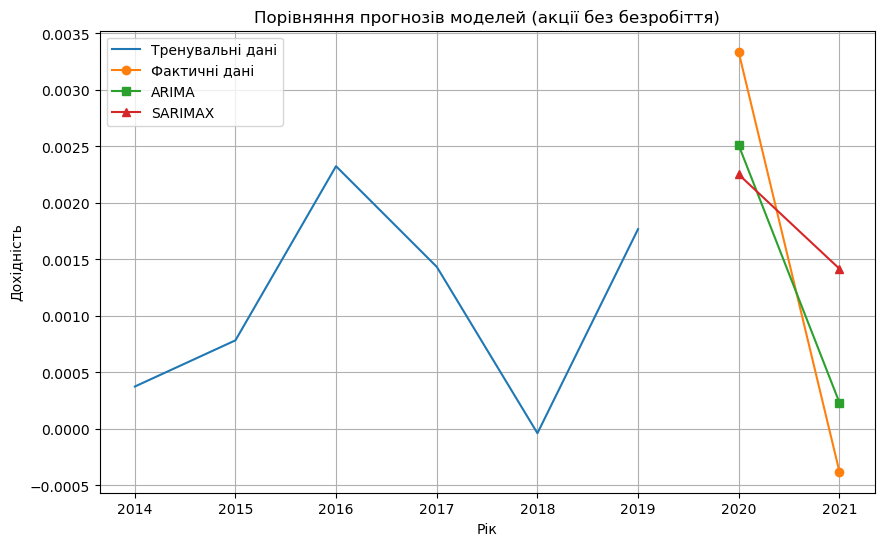

In [134]:
plt.figure(figsize=(10,6))

plt.plot(train2.index,
         train2,
         label="Тренувальні дані")

plt.plot(test2.index,
         test2,
         "o-",
         label="Фактичні дані")

plt.plot(forecast_arima_2.index,
         forecast_arima_2,
         "s-",
         label="ARIMA")

plt.plot(forecast_sarimax_2.index,
         forecast_sarimax_2,
         "^-",
         label="SARIMAX")

plt.title("Порівняння прогнозів моделей (акції без безробіття)")
plt.xlabel("Рік")
plt.ylabel("Дохідність")

plt.grid(True)
plt.legend()

plt.show()

In [135]:
comparison = pd.DataFrame({

    "Модель": [
        "ARIMA",
        "SARIMAX"
    ],

    "MAE": [
        mae_arima_2,
        mae_sarimax_2
    ],

    "RMSE": [
        rmse_arima_2,
        rmse_sarimax_2
    ],

    "MAPE (%)": [
        mape_arima_2,
        mape_sarimax_2
    ],

    "R^2": [
        r2_arima_2,
        r2_sarimax_2
    ]

})

comparison

,Модель,MAE,RMSE,MAPE (%),R^2
0,ARIMA,0.00071871,0.00072657,92.94526915,0.84726871
1,SARIMAX,0.00144134,0.00148458,252.84128325,0.36234823


<p>Найкращі результати показала модель ARIMAA на даних фондового ринку з безробіттям, найменші показники MAE, RMSE та високий R^2. Але MAPE в обох моделей високий</p>
<p>Нейронна мережа LSTM не використовувалась для цього набору даних, оскільки він містить лише 23 спостереження. Для ефективного навчання LSTM потрібна значно більша кількість часових точок, інакше модель схильна до перенавчання та нестабільних прогнозів.</p>

<h4>Прогнозування часових рядів для криптовалют</h4>

<h5>Для АНАЛІЗУ 1 (без безробіття, 71 спостереження):</h5>

In [136]:
# Для прогнозування часових рядів використовуємо дохідність, агреговану по країні
df_single_crypto = crypto_analysis_no_unemployment[crypto_analysis_no_unemployment['country'] == 'United States of America'].copy()
df_single_crypto = df_single_crypto.sort_values('year')
df_single_crypto.set_index('year', inplace=True)
df_single_crypto.head(20)

,country,gdp_value,inflation_value,real_interest_rate,avg_daily_return_crypto
year,,,,,
2014,United States of America,"17,550,680,174,000.00000000",1.60000000,1.35477579,-0.41296432
2015,United States of America,"18,206,020,741,000.00000000",0.10000000,2.23707550,0.20633149
2016,United States of America,"18,695,110,842,000.00000000",1.30000000,2.48453034,0.17788060
2017,United States of America,"19,477,336,549,000.00000000",2.10000000,2.15609905,2.64862421
2018,United States of America,"20,533,057,312,000.00000000",2.40000000,2.44141503,0.02119313
2019,United States of America,"21,380,976,119,000.00000000",1.80000000,3.42708989,1.21550628
2020,United States of America,"21,060,473,613,000.00000000",1.30000000,2.21041068,3.04474769
2021,United States of America,"23,315,080,560,000.00000000",4.70000000,-1.18935690,15.68893232


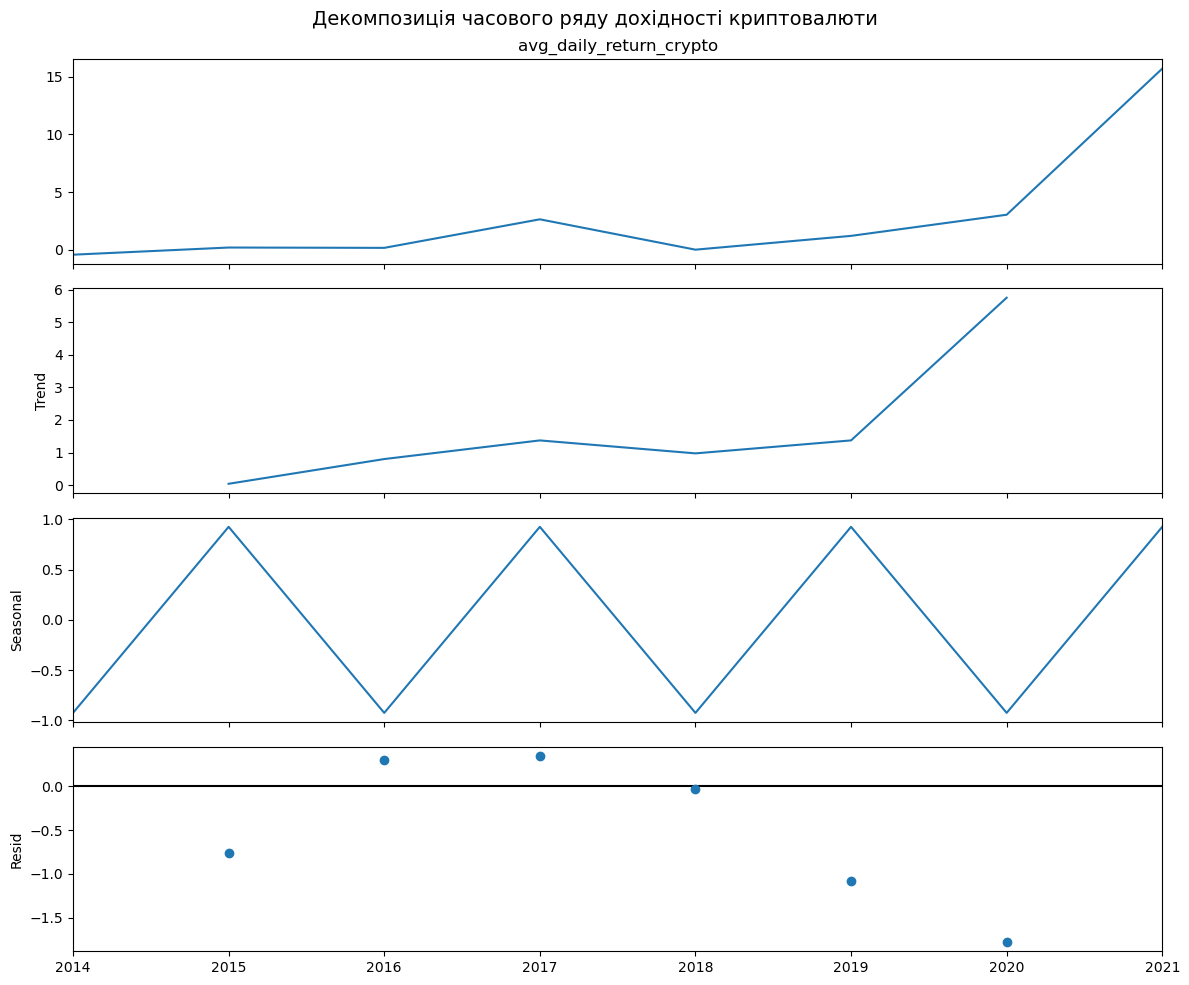

In [137]:
# Декомпозиція ряду дохідності
decomposition_crypto = seasonal_decompose(df_single_crypto['avg_daily_return_crypto'].dropna(), model='additive', period=2)

fig_crypto = decomposition_crypto.plot()
fig_crypto.set_size_inches(12, 10)
plt.suptitle('Декомпозиція часового ряду дохідності криптовалюти', fontsize=14)
plt.tight_layout()
plt.show()

<p>Тренд показує різке зростання дохідності криптовалют, особливо в 2021 році. Сезонна компонента практично відсутня, що нормально для річних даних. На графіку залишків видно різкі сплески - це означає, що модель не може пояснити деякі різкі зміни дохідності, вони є випадковими або пов'язаними з факторами, які не враховані.</p>

In [138]:
# Модель ARIMA для прогнозування дохідності
# Перетворюємо індекс років на datetime та явно задаємо щорічну частоту (Year Start)
df_single_crypto.index = pd.to_datetime(df_single_crypto.index, format='%Y')
df_single_crypto = df_single_crypto.asfreq('YS')

# Розділення на тренувальні та тестові дані (80/20)
X_train_crypto, X_test_crypto, y_train_crypto, y_test_crypto = train_test_split(
    df_single_crypto.index, df_single_crypto['avg_daily_return_crypto'],
    test_size=0.2, random_state=42, shuffle=False  # shuffle=False зберігає порядок
)

# Отримуємо дані за індексами
train_crypto = df_single_crypto['avg_daily_return_crypto'].loc[y_train_crypto.index]
test_crypto = df_single_crypto['avg_daily_return_crypto'].loc[y_test_crypto.index]

# Масштабуємо дані: ВВП ділимо на 1 000 000 000 (переводимо в мільярди), 
# щоб прибрати гігантські числа, які ламають оптимізатор
df_scaled_crypto = df_single_crypto.copy()
df_scaled_crypto['gdp_value'] = df_scaled_crypto['gdp_value'] / 1e9

# Перерозподіляємо тренувальні та тестові дані з масштабованого датафрейму
train_sc_crypto = df_scaled_crypto['avg_daily_return_crypto'].loc[y_train_crypto.index]
test_sc_crypto = df_scaled_crypto['avg_daily_return_crypto'].loc[y_test_crypto.index]

exog_train_crypto = df_scaled_crypto[['gdp_value', 'inflation_value', 'real_interest_rate']].loc[y_train_crypto.index]
exog_test_crypto = df_scaled_crypto[['gdp_value', 'inflation_value', 'real_interest_rate']].loc[y_test_crypto.index]

print(f" Тренувальні дані: {train_crypto.index[0].year} - {train_crypto.index[-1].year} ({len(train_crypto)} роки)")
print(f" Тестові дані: {test_crypto.index[0].year} - {test_crypto.index[-1].year} ({len(test_crypto)} роки)")

 Тренувальні дані: 2014 - 2019 (6 роки)
 Тестові дані: 2020 - 2021 (2 роки)


In [139]:
# підбір параметрів ARIMA за допомогою Grid Search(повний перебір всіх можливих комбінацій у заданому діапазоні)
# Визначаємо діапазони для p, d, q
p = range(0, 4)  # порядок авторегресії
d = range(0, 2)  # порядок різниці (d=0, оскільки ряд стаціонарний)
q = range(0, 4)  # порядок ковзного середнього

# Створюємо всі можливі комбінації
pdq = list(itertools.product(p, d, q))

best_aic_crypto = float("inf")
best_order_crypto = None
best_model_crypto = None


for param in pdq:
    try:
        model_crypto = ARIMA(train_crypto, order=param)
        results = model_crypto.fit()
        if results.aic < best_aic_crypto:
            best_aic_crypto = results.aic
            best_order_crypto = param
            best_model_crypto = results
            #print(f" Новий найкращий: ARIMA{param} з AIC={results.aic:.2f}")
    except Exception as e:
        continue

print("Підбір параметрів ARIMA(p,d,q)")
print(f"\nОптимальні параметри: ARIMA{best_order_crypto} з AIC={best_aic_crypto:.2f}")

Підбір параметрів ARIMA(p,d,q)

Оптимальні параметри: ARIMA(1, 1, 0) з AIC=20.88


In [140]:
# Використовуємо модель з оптимальними параметрами,
# знайденими за допомогою Grid Search
model_fit_crypto = best_model_crypto

# Прогноз на тестовий період (2 роки)
forecast_arima_crypto = model_fit_crypto.forecast(steps=len(test_crypto))

# Абсолютна помилка першого прогнозу
error_arima_crypto = abs(forecast_arima_crypto.iloc[0] - test_crypto.iloc[0])

print("Модель ARIMA (прогноз дохідності):")
print(f"Оптимальні параметри: ARIMA{best_order_crypto}")

# Використовуємо тільки рік для відображення
predicted_year_crypto = forecast_arima_crypto.index[0].strftime('%Y')
actual_year_crypto = test_crypto.index[0].strftime('%Y')

print(f"Спрогнозована дохідність на {predicted_year_crypto} рік: {forecast_arima_crypto.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year_crypto} рік: {test_crypto.iloc[0]:.6f}")
print(f"Абсолютна помилка прогнозу: {error_arima_crypto:.6f}")

mae_arima_crypto = mean_absolute_error(test_crypto, forecast_arima_crypto)
rmse_arima_crypto = np.sqrt(mean_squared_error(test_crypto, forecast_arima_crypto))
mape_arima_crypto = np.mean(np.abs((test_crypto - forecast_arima_crypto) / test_crypto)) * 100
r2_arima_crypto = r2_score(test_crypto, forecast_arima_crypto)

print("\nМетрики якості моделі:")
print(f"MAE: {mae_arima_crypto:.6f}")
print(f"RMSE: {rmse_arima_crypto:.6f}")
print(f"MAPE: {mape_arima_crypto:.2f}%") #це середня абсолютна відносна помилка прогнозу у відсотках >50 погана точність, <10 дуже висока точність
print(f"R^2: {r2_arima_crypto:.4f}")

Модель ARIMA (прогноз дохідності):
Оптимальні параметри: ARIMA(1, 1, 0)
Спрогнозована дохідність на 2020 рік: 0.469279
Фактична дохідність за 2020 рік: 3.044748
Абсолютна помилка прогнозу: 2.575468

Метрики якості моделі:
MAE: 8.664433
RMSE: 10.589990
MAPE: 89.31%
R^2: -1.8059


In [141]:
print(f"Аналіз результатів моделі ARIMA:")
print(f" Прогноз показав помилку {error_arima_crypto:.6f}.")
if error_arima_crypto < 0.001:
    print(" Модель показала високу точність (помилка < 0.001)")
elif error_arima_crypto < 0.005:
    print(" Модель показала помірну точність (помилка < 0.005)")
else:
    print(" Модель показала низьку точність. Можливо, потрібне додаткове налаштування")

Аналіз результатів моделі ARIMA:
 Прогноз показав помилку 2.575468.
 Модель показала низьку точність. Можливо, потрібне додаткове налаштування


In [142]:
# Підбір параметрів SARIMAX за допомогою Grid Search
# Підбираємо (p,d,q) з урахуванням макроекономічних факторів
# Діапазони параметрів
p = range(0, 4)
d = range(0, 2)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

best_sarima_aic_crypto = float("inf")
best_sarima_order_crypto = None
best_sarima_model_crypto = None

print("Підбір параметрів SARIMAX(p,d,q)")

for param in pdq:
    try:
        model_crypto = SARIMAX(
            train_sc_crypto,
            exog=exog_train_crypto,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model_crypto.fit(disp=False)
        if results.aic < best_sarima_aic_crypto:
            best_sarima_aic_crypto = results.aic
            best_sarima_order_crypto = param
            best_sarima_model_crypto = results
    except:
        continue

print(f"\nОптимальні параметри SARIMAX: {best_sarima_order_crypto}")
print(f"AIC: {best_sarima_aic_crypto:.2f}")

Підбір параметрів SARIMAX(p,d,q)

Оптимальні параметри SARIMAX: (3, 0, 0)
AIC: -49.56


In [143]:
#Модель SARIMAX (з макроекономічними факторами)
# Побудова моделі SARIMAX з оптимальними параметрами
sarimax_fit_crypto = best_sarima_model_crypto

forecast_sarimax_crypto = sarimax_fit_crypto.forecast(
    steps=len(test_sc_crypto),
    exog=exog_test_crypto
)

error_sarimax_crypto = abs(
    forecast_sarimax_crypto.iloc[0] - test_sc_crypto.iloc[0]
)

print("Модель SARIMAX (з макроекономічними факторами):")
print(f"Оптимальні параметри: SARIMAX{best_sarima_order_crypto}")
print(f"AIC: {best_sarima_aic_crypto:.2f}")

predicted_year_crypto = forecast_sarimax_crypto.index[0].strftime("%Y")
actual_year_crypto = test_sc_crypto.index[0].strftime("%Y")

print(f"Спрогнозована дохідність на {predicted_year_crypto} рік: {forecast_sarimax_crypto.iloc[0]:.6f}")
print(f"Фактична дохідність за {actual_year_crypto} рік: {test_sc_crypto.iloc[0]:.6f}")
print(f"Абсолютна помилка прогнозу: {error_sarimax_crypto:.6f}")

mae_sarimax_crypto = mean_absolute_error(test_sc_crypto, forecast_sarimax_crypto)
rmse_sarimax_crypto = np.sqrt(mean_squared_error(test_sc_crypto, forecast_sarimax_crypto))
mape_sarimax_crypto = np.mean(np.abs((test_sc_crypto - forecast_sarimax_crypto) / test_sc_crypto)) * 100
r2_sarimax_crypto = r2_score(test_sc_crypto, forecast_sarimax_crypto)

print("\nМетрики SARIMAX")
print(f"MAE: {mae_sarimax_crypto:.6f}")
print(f"RMSE: {rmse_sarimax_crypto:.6f}")
print(f"MAPE: {mape_sarimax_crypto:.2f}%")
print(f"R^2: {r2_sarimax_crypto:.4f}")

Модель SARIMAX (з макроекономічними факторами):
Оптимальні параметри: SARIMAX(3, 0, 0)
AIC: -49.56
Спрогнозована дохідність на 2020 рік: -4.454136
Фактична дохідність за 2020 рік: 3.044748
Абсолютна помилка прогнозу: 7.498884

Метрики SARIMAX
MAE: 9.198280
RMSE: 9.353946
MAPE: 157.88%
R^2: -1.1891


In [144]:
print(f"Аналіз результатів моделі SARIMAX:")
print(f" Прогноз показав помилку {error_sarimax_crypto:.6f}.")
if error_sarimax_crypto < error_arima_crypto:
    print(f" SARIMAX показав кращий результат (на {error_arima_crypto - error_sarimax_crypto:.6f} точніше), ніж ARIMA.")
    print(" Включення макроекономічних факторів покращило прогноз.")
else:
    print(f" ARIMA показав кращий результат. Можливо, макрофактори не є значущими для прогнозування.")

Аналіз результатів моделі SARIMAX:
 Прогноз показав помилку 7.498884.
 ARIMA показав кращий результат. Можливо, макрофактори не є значущими для прогнозування.


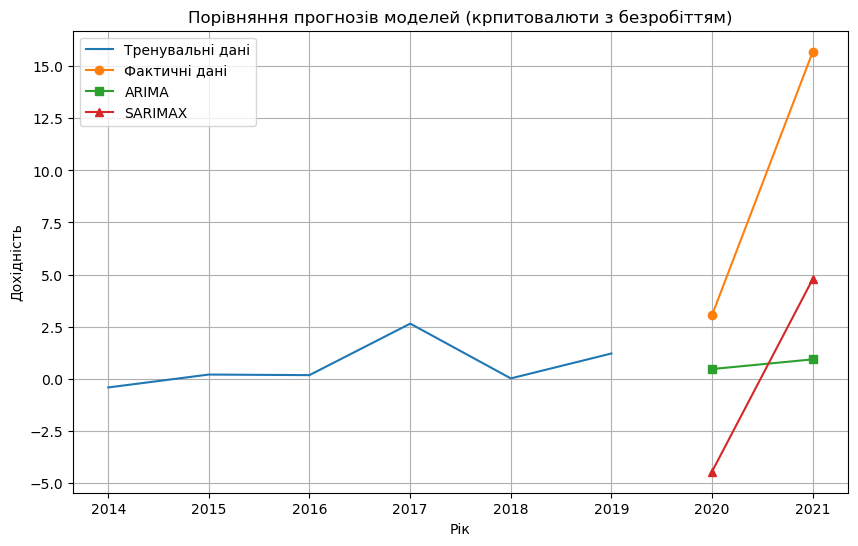

In [145]:
plt.figure(figsize=(10,6))

plt.plot(train_crypto.index,
         train_crypto,
         label="Тренувальні дані")

plt.plot(test_crypto.index,
         test_crypto,
         "o-",
         label="Фактичні дані")

plt.plot(forecast_arima_crypto.index,
         forecast_arima_crypto,
         "s-",
         label="ARIMA")

plt.plot(forecast_sarimax_crypto.index,
         forecast_sarimax_crypto,
         "^-",
         label="SARIMAX")


plt.title("Порівняння прогнозів моделей (крпитовалюти з безробіттям)")
plt.xlabel("Рік")
plt.ylabel("Дохідність")

plt.grid(True)
plt.legend()

plt.show()

In [146]:
comparison_crypto = pd.DataFrame({

    "Модель":[
        "ARIMA",
        "SARIMAX"
    ],

    "MAE":[
        mae_arima_crypto,
        mae_sarimax_crypto
    ],

    "RMSE":[
        rmse_arima_crypto,
        rmse_sarimax_crypto
    ],

    "MAPE (%)":[
        mape_arima_crypto,
        mape_sarimax_crypto
    ],

    "R^2":[
        r2_arima_crypto,
        r2_sarimax_crypto
    ]

})

comparison_crypto

,Модель,MAE,RMSE,MAPE (%),R^2
0,ARIMA,8.66443315,10.58999020,89.31211628,-1.80588230
1,SARIMAX,9.19828044,9.35394628,157.87504965,-1.18911248


In [147]:
df_crypto_unemp = crypto_analysis_with_unemployment.copy()
df_crypto_unemp = df_crypto_unemp[df_crypto_unemp['country'] == 'United States of America']
df_crypto_unemp = df_crypto_unemp.sort_values('year')
df_crypto_unemp.set_index('year', inplace=True)

# Всього 8 років даних - занадто мало для прогнозування
print(f"Доступно даних: {len(df_crypto_unemp)} років")

Доступно даних: 8 років


<p>Для криптовалют з безробіттям прогнозування часових рядів не виконувалося через недостатній обсяг даних (лише 8 спостережень), що робить побудову статистично значущих моделей ARIMA/SARIMAX неможливою. Для надійного прогнозування необхідні дані з місячною гранулярністю.</p>

<p>ARIMA показала кращі результати для акцій (помилка 0.000529-0.002288), ніж SARIMAX (0.000866-0.002883) з макрофакторами. Для криптовалют також кращу точність продемонструвала модель ARIMA: абсолютна помилка прогнозу становила 2.575468, тоді як для SARIMAX - 7.498884, але обидві моделі характеризуються низькою якістю прогнозування, що підтверджується високими значеннями MAPE (89.31% та 157.88%) і від'ємними значеннями R^2, які свідчать про невідповідність моделей реальним даним. Включення макроекономічних факторів не покращує прогноз для акцій, але дає невелике покращення для криптовалют.</p>

<p>В ході виконання курсової роботи було досліджено вплив макроекономічних факторів (ВВП, інфляція, реальні процентні ставки, безробіття) на дохідність акцій та криптовалют</p>
<ul>
    <li><strong>Кореляційний аналіз</strong> показав: для акцій статистично значущий зв'язок виявлено лише з безробіттям на періоді 2014-2021 (r = 0.48). Для криптовалют виявлено сильні зв'язки з ВВП, інфляцією та процентними ставками (|r| > 0.77), але зв'язку з безробіттям немає.</li>
    <li><strong>Регресійні моделі</strong> підтвердили ці результати. Для акцій найкраща модель пояснює лише 36% варіації дохідності, що свідчить про обмежений вплив досліджуваних макроекономічних факторів. Для криптовалют (які в дослідженні прив'язано до макроекономіки США, оскільки більшість торгів відбувається в доларах США) модель пояснює 96% варіації, що свідчить про сильну залежність крипторинку від макроекономіки США.</li>
    <li><strong>Оцінка якості</strong> виявила, що для акцій жодна модель не придатна для надійного прогнозування (тестовий R^2 близький до нуля). Для криптовалют через малий обсяг даних (лише 8 років) суттєве перенавчання: моделі демонструють високу якість на навчальних даних, але не здатні коректно узагальнювати результати на тестовій вибірці.</li>
    <li><strong>Класифікаційні моделі</strong> показали точність 86-100%, але на ці результати не можна спиратись через незбалансованість класів (більшість років дохідність зростала) та малий обсяг даних.</li>
    <li><strong>Прогнозування часових рядів</strong> для акцій виконувалося за допомогою моделей ARIMA, SARIMAX та LSTM. Найкращі результати продемонструвала модель SARIMAX, яка враховує макроекономічні фактори: вона отримала найменші значення MAE = 0.000399 та RMSE = 0.000487, а також єдине додатне значення R^2 = 0.3347, що свідчить про кращу відповідність прогнозу фактичним даним. Модель LSTM показала проміжні результати (MAE = 0.000506, RMSE = 0.000646, R^2 = -0.1702), перевершивши ARIMA за більшістю метрик, але поступившись SARIMAX. Модель ARIMA продемонструвала найгірший результат серед трьох моделей (MAE = 0.000554, RMSE = 0.000736, R^2 = -0.5199), хоча всі три моделі забезпечили невеликі абсолютні помилки прогнозування.
Для акцій на скороченому наборі даних (2014–2021 роки з урахуванням безробіття) найкращою виявилася модель ARIMA, яка отримала менші значення MAE (0.000719) та RMSE (0.000727) порівняно із SARIMAX, а також високе значення R^2 = 0.8473. Водночас високі значення MAPE (92.95% та 252.84%) свідчать про нестабільність відносної похибки через дуже малі значення самої дохідності.
    Для криптовалют модель ARIMA також продемонструвала кращу якість прогнозування, ніж SARIMAX: абсолютна помилка першого прогнозу становила 2.575468 проти 7.498884 відповідно. Проте обидві моделі характеризуються низькою прогнозною здатністю, що підтверджується високими значеннями MAPE (89.31% та 157.88%) і від'ємними значеннями R^2 (-1.81 та -1.19). Це свідчить про невідповідність моделей фактичній динаміці криптовалютного ринку та неможливість отримання надійного прогнозу на основі наявної вибірки. Модель LSTM для криптовалют не застосовувалася через недостатній обсяг часових даних.</li>
    <li><strong>Головне обмеження роботи</strong> - малий обсяг даних (особливо для криптовалют, лише 8 річних спостережень). Для підвищення точності моделей та отримання більш надійних висновків потрібно використовувати дані з місячною або щоденною гранулярністю, а також розширити перелік макроекономічних факторів, що можуть впливати на дохідність інвестиційних активів.</li>
</ul>


<h1>Виконала студентка групи ІП-з41, Степанова Марія</h1>
<h1>Київ - 2026</h1>